In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# folders we will use
os.makedirs("cleaned_results", exist_ok=True)
os.makedirs("merged_results", exist_ok=True)

# your raw files (edit ONLY if your names differ)
raw_files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP_1": "Rtp_1.csv",
    "RTP_2": "RTP_2.csv",
}

# quick check: make sure files exist
missing = [f for f in raw_files.values() if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Missing these files in your folder: {missing}")

print("✅ Cell 1 done. All files found.")

✅ Cell 1 done. All files found.


In [14]:
# Load RTP1 + RTP2
rtp1 = pd.read_csv(raw_files["RTP_1"])
rtp2 = pd.read_csv(raw_files["RTP_2"])

# Clean column names (strip spaces)
rtp1.columns = rtp1.columns.astype(str).str.strip()
rtp2.columns = rtp2.columns.astype(str).str.strip()

# Add City column before combining
rtp1["City"] = "RTP"
rtp2["City"] = "RTP"

# Combine and drop exact duplicate rows
rtp_raw = pd.concat([rtp1, rtp2], ignore_index=True).drop_duplicates()

# Save merged RTP raw file
rtp_raw_path = "RTP_raw_combined.csv"
rtp_raw.to_csv(rtp_raw_path, index=False)

print("✅ RTP merged and saved:", rtp_raw_path)
print("Rows:", len(rtp_raw))
print("Columns:", list(rtp_raw.columns))

✅ RTP merged and saved: RTP_raw_combined.csv
Rows: 20721
Columns: ['Unnamed: 0', 'hr', 'city', 'id', 'RH', 'PA', 'ref', 'monitortype', 'State', 'week', 'adj', 'adjtype', 'wholdtype', 'City']


In [15]:
cities = {
    "Bend": raw_files["Bend"],
    "Oakridge": raw_files["Oakridge"],
    "Wilmington": raw_files["Wilmington"],
    "RTP": "RTP_raw_combined.csv",   # merged RTP
}

print("Cities ready for cleaning:")
for k, v in cities.items():
    print(f"{k} → {v}")

Cities ready for cleaning:
Bend → bend.csv
Oakridge → Oakridge.csv
Wilmington → Wilmington.csv
RTP → RTP_raw_combined.csv


In [16]:
# CELL 4 — Set latitude/longitude for each city (EDIT if needed)

city_coords = {
    "Bend":       {"lat": 44.0582, "lon": -121.3153},
    "Oakridge":   {"lat": 43.7465, "lon": -122.4617},
    "Wilmington": {"lat": 34.2257, "lon": -77.9447},
    "RTP":        {"lat": 35.9049, "lon": -78.8646},   # Research Triangle Park area
}

# Save meteo outputs here
os.makedirs("meteo_results", exist_ok=True)

print("✅ Cell 4 done. Coords loaded for:", list(city_coords.keys()))

✅ Cell 4 done. Coords loaded for: ['Bend', 'Oakridge', 'Wilmington', 'RTP']


In [17]:
# CELL 5 — Helper: build date range from each city's hr column (no warnings)

def get_date_range_from_file(csv_path, hr_col="hr"):
    df = pd.read_csv(csv_path, usecols=[hr_col])
    hr = pd.to_datetime(df[hr_col], errors="coerce")   # handles m/d/y and y-m-d
    hr = hr.dropna()
    if hr.empty:
        raise ValueError(f"No valid timestamps found in {csv_path} column '{hr_col}'")
    start_date = hr.min().date().isoformat()
    end_date   = hr.max().date().isoformat()
    return start_date, end_date

print("✅ Cell 5 done.")

✅ Cell 5 done.


In [18]:
# CELL 6 — Fetch hourly meteorology from Open-Meteo (temp, windspeed, winddirection)

def fetch_open_meteo_hourly(lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,windspeed_10m,winddirection_10m",
        "timezone": "UTC",
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    hourly = js.get("hourly", {})
    out = pd.DataFrame({
        "hr": pd.to_datetime(hourly.get("time", []), errors="coerce"),
        "temp_C": hourly.get("temperature_2m", []),
        "wind_speed": hourly.get("windspeed_10m", []),
        "wind_dir": hourly.get("winddirection_10m", []),
    })

    out = out.dropna(subset=["hr"]).sort_values("hr").reset_index(drop=True)
    return out

print("✅ Cell 6 done.")

✅ Cell 6 done.


In [19]:
# CELL 7 — Download meteo for each city and save to meteo_results/

meteo_files = {}

for city, csv_path in cities.items():
    if city not in city_coords:
        raise ValueError(f"Missing coordinates for city: {city}")

    start_date, end_date = get_date_range_from_file(csv_path, hr_col="hr")
    lat, lon = city_coords[city]["lat"], city_coords[city]["lon"]

    meteo_df = fetch_open_meteo_hourly(lat, lon, start_date, end_date)

    out_path = os.path.join("meteo_results", f"{city}_meteo_hourly.csv")
    meteo_df.to_csv(out_path, index=False)
    meteo_files[city] = out_path

    print(f"✅ {city}: meteo saved → {out_path} | rows={len(meteo_df)} | {start_date} to {end_date}")

print("✅ Cell 7 done. Meteo files:", meteo_files)

/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/3888659328.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hr = pd.to_datetime(df[hr_col], errors="coerce")   # handles m/d/y and y-m-d


✅ Bend: meteo saved → meteo_results/Bend_meteo_hourly.csv | rows=1920 | 2020-08-01 to 2020-10-19


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/3888659328.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hr = pd.to_datetime(df[hr_col], errors="coerce")   # handles m/d/y and y-m-d


✅ Oakridge: meteo saved → meteo_results/Oakridge_meteo_hourly.csv | rows=1920 | 2020-08-01 to 2020-10-19


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/3888659328.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hr = pd.to_datetime(df[hr_col], errors="coerce")   # handles m/d/y and y-m-d


✅ Wilmington: meteo saved → meteo_results/Wilmington_meteo_hourly.csv | rows=8160 | 2019-07-27 to 2020-06-30


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/3888659328.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hr = pd.to_datetime(df[hr_col], errors="coerce")   # handles m/d/y and y-m-d


✅ RTP: meteo saved → meteo_results/RTP_meteo_hourly.csv | rows=6048 | 2019-03-13 to 2019-11-19
✅ Cell 7 done. Meteo files: {'Bend': 'meteo_results/Bend_meteo_hourly.csv', 'Oakridge': 'meteo_results/Oakridge_meteo_hourly.csv', 'Wilmington': 'meteo_results/Wilmington_meteo_hourly.csv', 'RTP': 'meteo_results/RTP_meteo_hourly.csv'}


In [20]:
# CELL (use this NOW) — Before vs After table without hardcoding filenames
# It will look inside cleaned_results/ and pick the right cleaned file automatically.

import os
import pandas as pd

raw_files_summary = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP_raw_combined.csv",
}

def find_clean_file(city):
    """
    Looks for a cleaned file for this city inside cleaned_results/.
    Accepts any of these patterns:
      cleaned_results/<city>_PM_weather_hourly_EDA_ready.csv
      cleaned_results/<city>_EDA_ready.csv
      cleaned_results/<city>_cleaned.csv
      cleaned_results/<city>_pm_cleaned.csv
    (case-insensitive)
    """
    city_low = city.lower().replace(" ", "").replace("_", "")

    if not os.path.isdir("cleaned_results"):
        raise FileNotFoundError("Folder 'cleaned_results' not found yet.")

    candidates = []
    for fn in os.listdir("cleaned_results"):
        fn_low = fn.lower().replace(" ", "").replace("_", "")
        if city_low in fn_low and fn_low.endswith(".csv"):
            candidates.append(os.path.join("cleaned_results", fn))

    # Prefer most "final" looking names
    priority = [
        "pmweatherhourlyedaready",
        "edaready",
        "pm_cleaned",
        "cleaned",
    ]
    for key in priority:
        for path in candidates:
            if key in os.path.basename(path).lower().replace(" ", "").replace("_", ""):
                return path

    if candidates:
        return candidates[0]

    raise FileNotFoundError(
        f"No cleaned CSV found for {city} in cleaned_results/. "
        f"Files there: {os.listdir('cleaned_results')}"
    )

rows = []

for city, raw_path in raw_files_summary.items():
    before_df = pd.read_csv(raw_path)

    clean_path = find_clean_file(city)  # auto-find
    after_df = pd.read_csv(clean_path)

    rows.append({
        "City": city,
        "Hourly observation before cleaning": len(before_df),
        "Hourly observation after cleaning": len(after_df),
        "Clean file used": os.path.basename(clean_path),
    })

summary_df = pd.DataFrame(rows)
summary_df.index = range(1, len(summary_df) + 1)

summary_df.style.format({
    "Hourly observation before cleaning": "{:,}",
    "Hourly observation after cleaning": "{:,}",
})

,City,Hourly observation before cleaning,Hourly observation after cleaning,Clean file used
1,Bend,"15,822","1,758",bend_pm_cleaned.csv
2,Oakridge,"16,785","1,865",oakridge_pm_cleaned.csv
3,Wilmington,"45,640","5,705",wilmington_pm_cleaned.csv
4,RTP,"20,721","1,921",Rtp_1_cleaned.csv


In [37]:
import pandas as pd
import os

# Your final EDA_ready files (adjust names ONLY if needed)
clean_files = {
    "Bend": "merged_results/Bend_PM_weather_hourly_EDA_ready.csv",
    "Oakridge": "merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv",
    "Wilmington": "merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv",
    "RTP": "merged_results/RTP_PM_weather_hourly_EDA_ready.csv",
}

for city, file in clean_files.items():
    
    if not os.path.exists(file):
        print(f"⚠ File not found for {city}: {file}")
        continue

    df = pd.read_csv(file)

    # Check if meteorology columns exist
    required_cols = ["temp_C", "wind_speed", "wind_dir"]
    
    if not all(col in df.columns for col in required_cols):
        print(f"{city}: Meteorology columns missing → {df.columns.tolist()}")
        continue

    missing_predictors = df[required_cols].isna().any(axis=1).sum()

    print(f"{city}: {missing_predictors} missing predictor observation(s)")

Bend: 0 missing predictor observation(s)
Oakridge: 0 missing predictor observation(s)
Wilmington: 0 missing predictor observation(s)
RTP: 0 missing predictor observation(s)


In [38]:
import pandas as pd

# Load BEFORE-merge raw files (your cities)
files = {
    "Bend": "bend.csv",
    "Oakridge": "Oakridge.csv",
    "Wilmington": "Wilmington.csv",
    "RTP": "RTP_raw_combined.csv",  # merged RTP1 + RTP2
}

dfs = []

for city, file in files.items():
    df = pd.read_csv(file)

    # Ensure consistent City column
    df["City"] = city

    dfs.append(df)

# Combine into one dataframe
data_before = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", data_before.shape)
print("Columns:", data_before.columns.tolist())

Combined dataset shape: (98968, 14)
Columns: ['Unnamed: 0', 'hr', 'city', 'id', 'RH', 'PA', 'ref', 'monitortype', 'State', 'week', 'adj', 'adjtype', 'wholdtype', 'City']


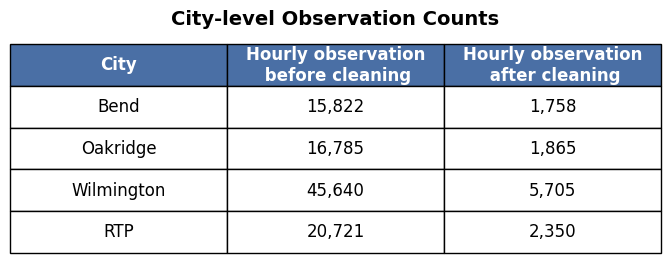

In [40]:
import matplotlib.pyplot as plt

data = [
    ["Bend", "15,822", "1,758"],
    ["Oakridge", "16,785", "1,865"],
    ["Wilmington", "45,640", "5,705"],
    ["RTP", "20,721", "2,350"]
]

columns = [
    "City",
    "Hourly observation\n before cleaning",
    "Hourly observation\n after cleaning"
]

fig, ax = plt.subplots(figsize=(7,3))
ax.axis('off')

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,2.5)

# header color
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4A6FA5")
        cell.set_text_props(color='white', weight='bold')

plt.title("City-level Observation Counts", fontsize=14, weight='bold')
plt.show()

In [41]:
type(data)

list

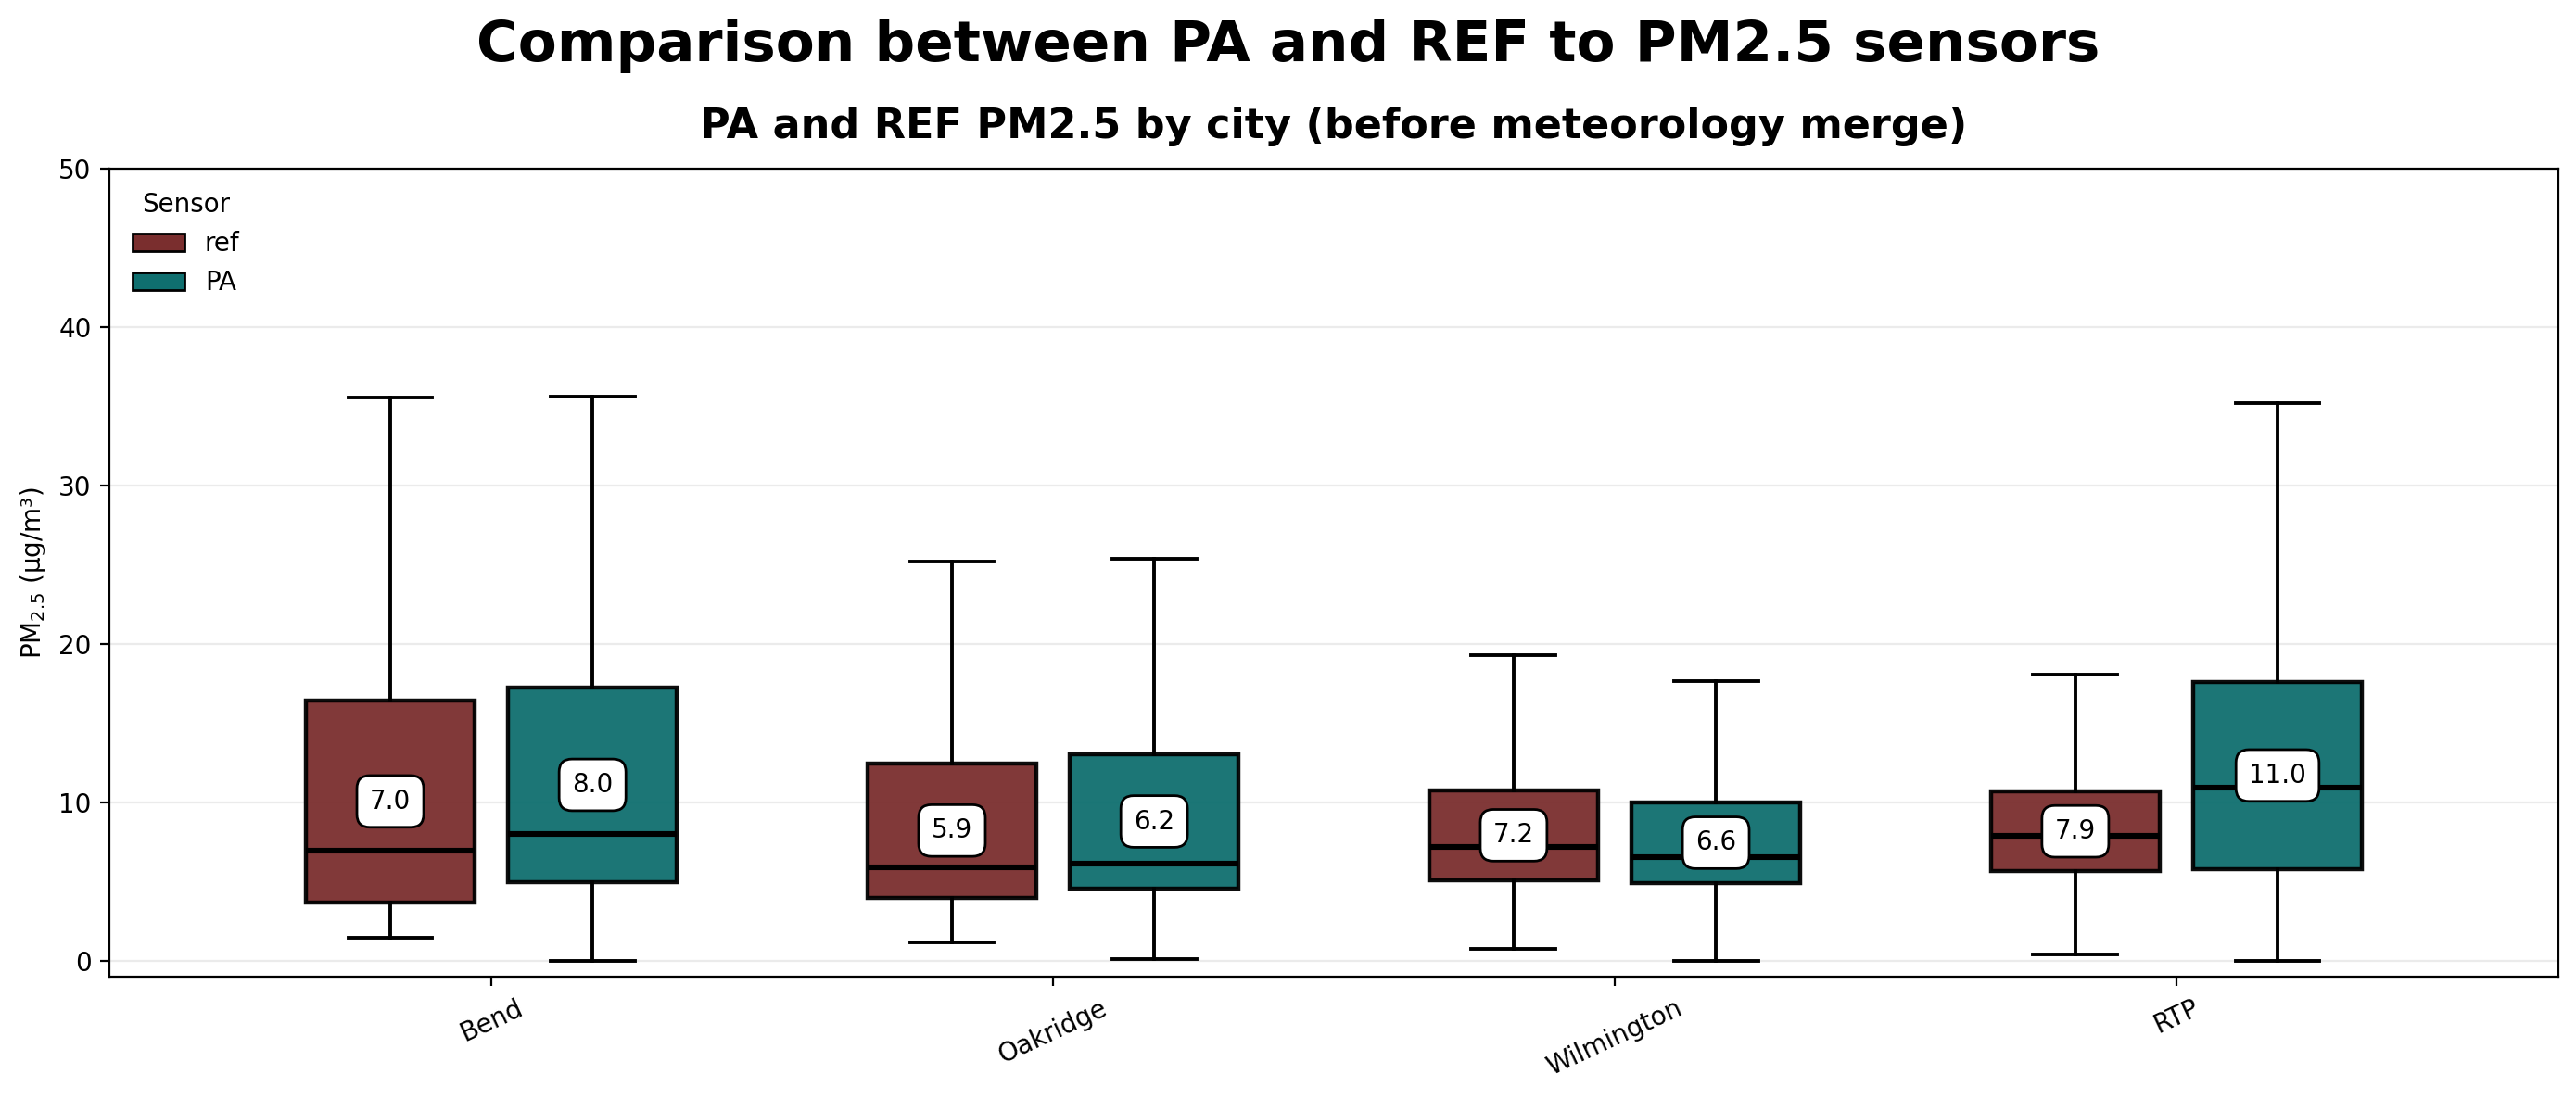

In [42]:
# === BEFORE METEOROLOGY MERGE (ONE GRAPH, REF & PA SIDE-BY-SIDE PER CITY) ===

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 1) Your input files (BEFORE meteo merge)
# -----------------------------
files = {
    "Bend":       "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge":   "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv",
    "RTP_1":      "cleaned_results/rtp1_pm_cleaned.csv",
    "RTP_2":      "cleaned_results/rtp2_pm_cleaned.csv",
}

missing = [p for p in files.values() if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Missing these files:\n" + "\n".join(missing) +
        "\n\nFix the paths OR put the CSVs inside cleaned_results/."
    )

city_order = ["Bend", "Oakridge", "Wilmington", "RTP"]

# -----------------------------
# 2) Load + standardize columns
# -----------------------------
dfs = []
for city, fp in files.items():
    df = pd.read_csv(fp)
    df.columns = df.columns.astype(str).str.strip()

    # Merge RTP_1 and RTP_2 into "RTP"
    df["City"] = "RTP" if city in ["RTP_1", "RTP_2"] else city

    # REF column
    if "ref" not in df.columns:
        raise ValueError(f"'ref' column not found in {fp}. Found columns: {df.columns.tolist()}")
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")

    # PurpleAir column can be PA / adj / pa
    if "PA" in df.columns:
        df["PA_val"] = pd.to_numeric(df["PA"], errors="coerce")
    elif "adj" in df.columns:
        df["PA_val"] = pd.to_numeric(df["adj"], errors="coerce")
    elif "pa" in df.columns:
        df["PA_val"] = pd.to_numeric(df["pa"], errors="coerce")
    else:
        raise ValueError(f"No 'PA' or 'adj' or 'pa' column found in {fp}. Found columns: {df.columns.tolist()}")

    dfs.append(df[["City", "ref", "PA_val"]])

data = pd.concat(dfs, ignore_index=True)

# remove NaNs + remove negatives
data = data.dropna(subset=["ref", "PA_val"])
data = data[(data["ref"] >= 0) & (data["PA_val"] >= 0)]

# -----------------------------
# 3) Plot styling helpers
# -----------------------------
ref_color = "#7A2E2E"   # maroon
pa_color  = "#0F6F6F"   # teal

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.6)
        box.set_alpha(0.95)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2.2)
    for whisker in bp["whiskers"]:
        whisker.set_color("black")
        whisker.set_linewidth(1.4)
    for cap in bp["caps"]:
        cap.set_color("black")
        cap.set_linewidth(1.4)

def add_median_label(ax, vals, x_pos):
    vals = np.asarray(vals)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return

    med = float(np.median(vals))
    q1  = np.percentile(vals, 25)
    q3  = np.percentile(vals, 75)

    # center of the box
    y_center = (q1 + q3) / 2

    ax.text(
        x_pos, y_center, f"{med:.1f}",
        ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.50",
                  facecolor="white",
                  edgecolor="black",
                  linewidth=1.0)
    )

legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color,  edgecolor="black", label="PA"),
]

# -----------------------------
# 4) Build ONE combined boxplot (REF & PA side-by-side per city)
# -----------------------------
ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().values for c in city_order]

x = np.arange(len(city_order))
offset = 0.18
width = 0.30

fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

# IMPORTANT: whiskers like typical boxplot; show fliers (outliers)
bp_ref = ax.boxplot(
    ref_vals, positions=x - offset, widths=width,
    patch_artist=True, showfliers=False, whis=1.5
)
bp_pa = ax.boxplot(
    pa_vals, positions=x + offset, widths=width,
    patch_artist=True, showfliers=False, whis=1.5
)

style_boxplot(bp_ref, ref_color)
style_boxplot(bp_pa, pa_color)

# median labels
for vals, pos in zip(ref_vals, x - offset):
    add_median_label(ax, vals, pos)
for vals, pos in zip(pa_vals, x + offset):
    add_median_label(ax, vals, pos)

# axes + labels
ax.set_xticks(x)
ax.set_xticklabels(city_order, rotation=25)
ax.set_ylabel("PM$_{2.5}$ (µg/m³)")

# TITLE + SUBTITLE (clean spacing)

fig.suptitle("Comparison between PA and REF to PM2.5 sensors", fontsize=22, fontweight="bold", y=0.98)
ax.set_title("PA and REF PM2.5 by city (before meteorology merge)", fontsize=16, fontweight="bold", pad=12)

# legend (no overlap)
ax.legend(handles=legend_handles, title="Sensor",
          loc="upper left", frameon=False)

ax.grid(axis="y", alpha=0.25)

# set your display range (you wanted typical range)
ax.set_ylim(-1, 50)

plt.tight_layout()
plt.show()

# Optional save for PPT:
# fig.savefig("pm25_ref_pa_by_city_before_meteo_merge.png", dpi=300, bbox_inches="tight")

In [43]:
import pandas as pd

files = {
    "Bend": "merged_results/Bend_PM_weather_hourly_EDA_ready.csv",
    "Oakridge": "merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv",
    "Wilmington": "merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv",
    "RTP": "merged_results/RTP_PM_weather_hourly_EDA_ready.csv",
}

dfs = []
for city, path in files.items():
    df = pd.read_csv(path)

    # Normalize City column
    if "City" not in df.columns and "city" in df.columns:
        df = df.rename(columns={"city": "City"})
    if "City" not in df.columns:
        df["City"] = city

    # Force labels to match keys
    df["City"] = city

    dfs.append(df)

data_after = pd.concat(dfs, ignore_index=True)

# Make sure ref is numeric
data_after["ref"] = pd.to_numeric(data_after["ref"], errors="coerce")

# Standardize PA column to "PA"
if "PA" in data_after.columns:
    data_after["PA"] = pd.to_numeric(data_after["PA"], errors="coerce")
elif "pa" in data_after.columns:
    data_after["PA"] = pd.to_numeric(data_after["pa"], errors="coerce")
elif "adj" in data_after.columns:
    data_after["PA"] = pd.to_numeric(data_after["adj"], errors="coerce")
else:
    raise ValueError(f"No PA/pa/adj column found. Columns: {data_after.columns.tolist()}")

# Confirm columns/rows
print("Columns:", list(data_after.columns))
print("Rows:", len(data_after))
data_after.head()

Columns: ['hr', 'city', 'id', 'rh', 'pa', 'ref', 'monitortype', 'state', 'week', 'adj', 'adjtype', 'wholdtype', 'City', 'temp_C', 'wind_speed', 'wind_dir', 'PA']
Rows: 11678


,hr,city,id,rh,pa,ref,monitortype,state,week,adj,adjtype,wholdtype,City,temp_C,wind_speed,wind_dir,PA
0,2020-08-01 00:00:00,Bend_S,Bend,40.600000,12.901833,8.0,not_specified,Bend,NaN,8.971420,E,LOSO,Bend,30.7,21.0,6,12.901833
1,2020-08-01 01:00:00,Bend_S,Bend,37.600000,12.561000,7.7,not_specified,Bend,NaN,8.975477,E,LOSO,Bend,29.4,18.6,342,12.561000
2,2020-08-01 02:00:00,Bend_S,Bend,36.733333,9.081333,6.1,not_specified,NaN,30.0,7.638520,E,LOBD,Bend,28.8,9.3,306,9.081333
3,2020-08-01 03:00:00,Bend_S,Bend,38.533333,7.491500,5.4,not_specified,NaN,30.0,6.914236,E,LOBD,Bend,26.4,5.8,22,7.491500
4,2020-08-01 04:00:00,Bend_S,Bend,41.333333,8.288833,5.8,not_specified,NaN,30.0,6.978674,D,LOBD,Bend,23.1,13.0,51,8.288833


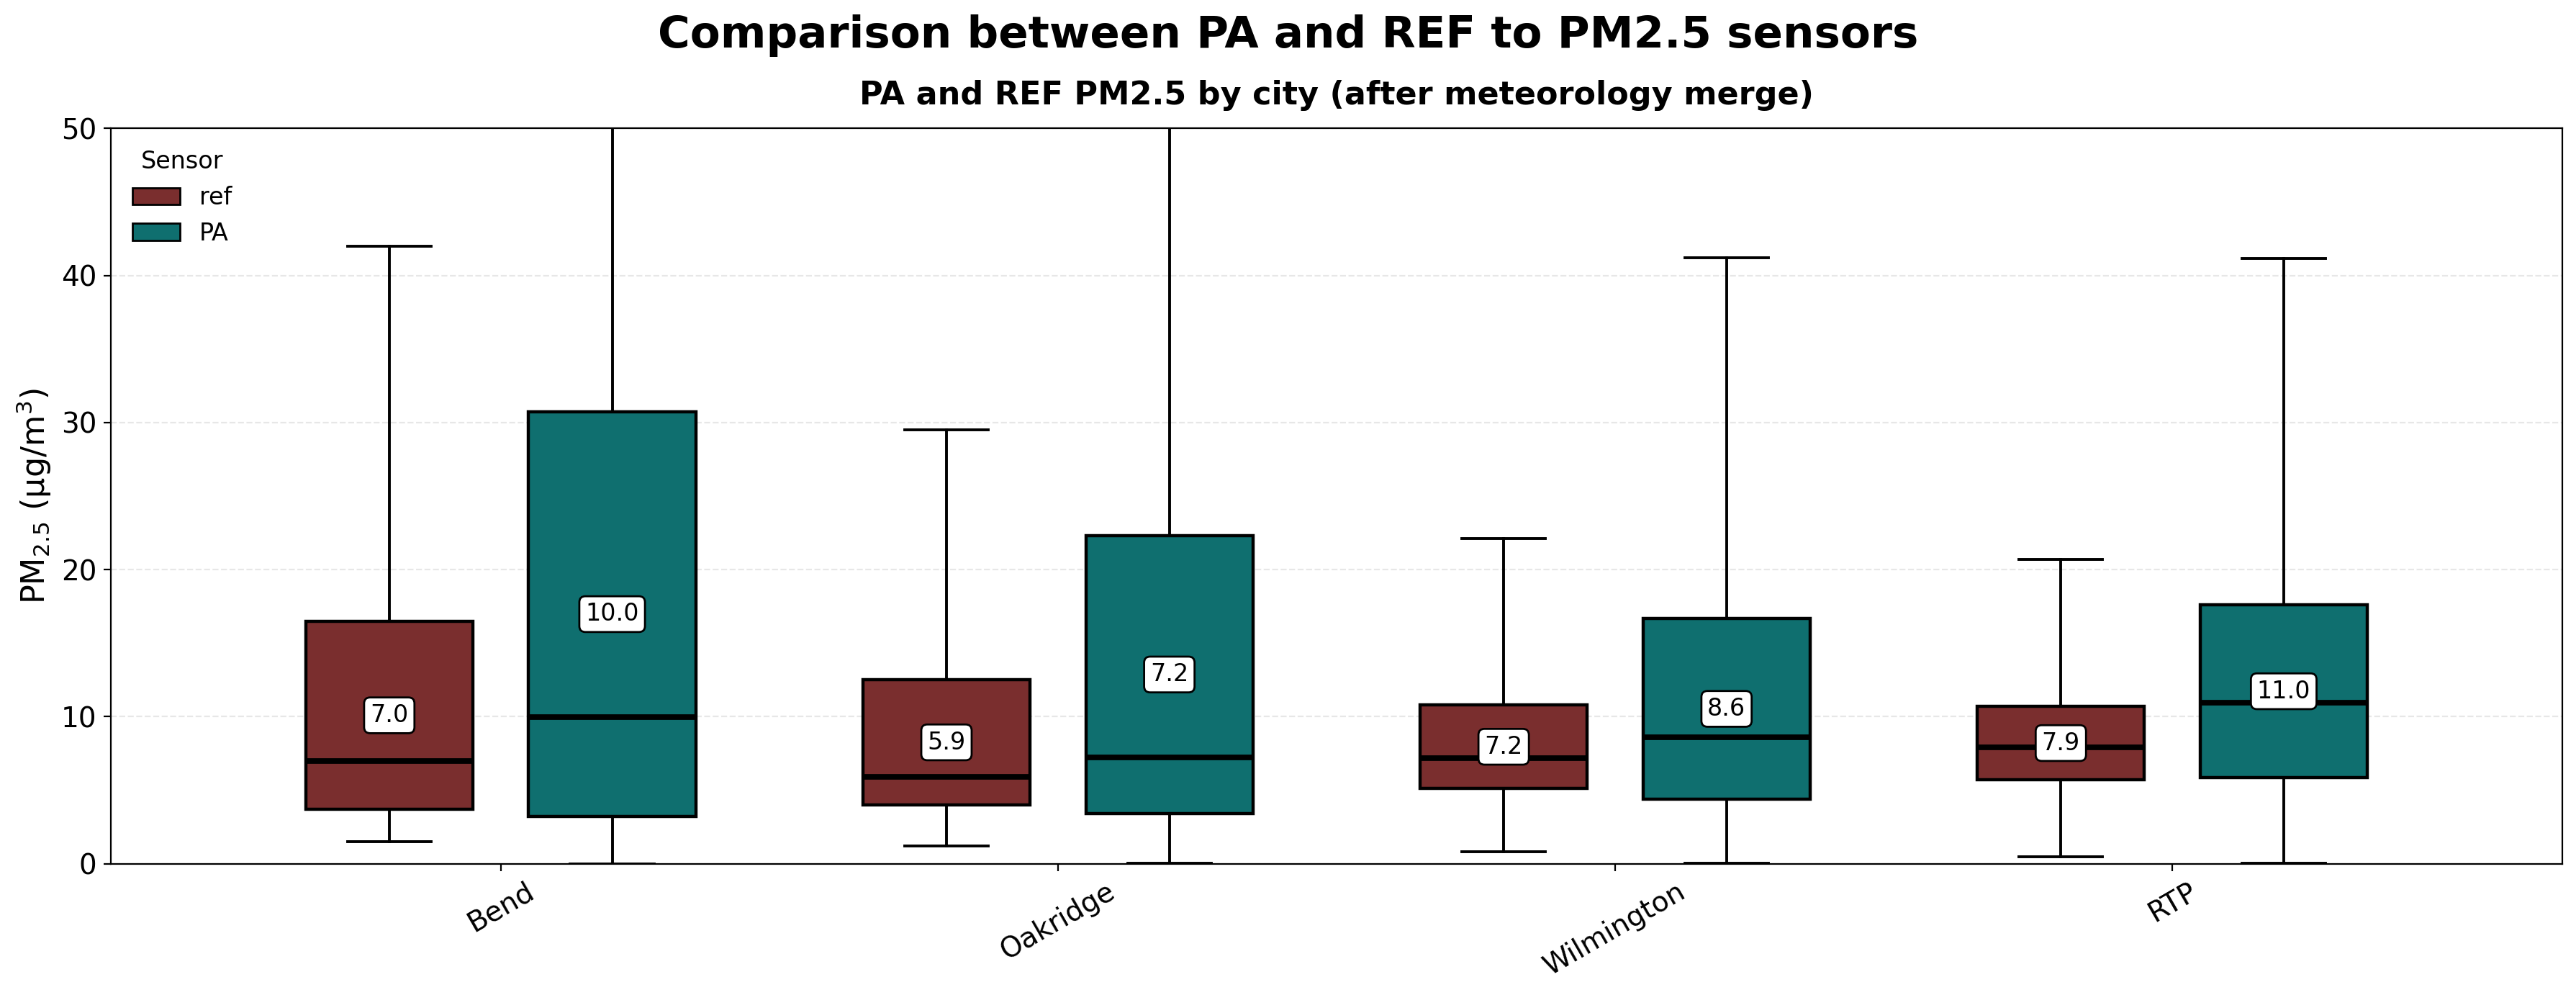

In [44]:
# CELL 6 (YOUR CITIES) — AFTER meteorology merge (EDA_ready) colored side-by-side boxplots (REF vs PA)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---- 1) Point to your AFTER-meteo files (edit names only if yours differ) ----
after_files = {
    "Bend":       "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge":   "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv",
    "RTP":        "cleaned_results/rtp_pm_cleaned.csv",
}

missing = [p for p in after_files.values() if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"These AFTER-meteo files are missing:\n{missing}\n"
                            f"Available in cleaned_results: {os.listdir('cleaned_results')}")

# ---- 2) Load + normalize columns ----
dfs = []
for city, fp in after_files.items():
    df = pd.read_csv(fp)
    df.columns = df.columns.astype(str).str.strip()
    df["City"] = city

    if "ref" not in df.columns:
        raise ValueError(f"'ref' column not found in {fp}. Columns: {df.columns.tolist()}")
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")

    if "PA" in df.columns:
        df["PA_val"] = pd.to_numeric(df["PA"], errors="coerce")
    elif "pa" in df.columns:
        df["PA_val"] = pd.to_numeric(df["pa"], errors="coerce")
    elif "adj" in df.columns:
        df["PA_val"] = pd.to_numeric(df["adj"], errors="coerce")
    else:
        raise ValueError(f"No PA column found in {fp} (expected 'PA' or 'pa' or 'adj'). "
                         f"Columns: {df.columns.tolist()}")

    dfs.append(df[["City", "ref", "PA_val"]])

data = pd.concat(dfs, ignore_index=True)

# ---- 3) Plot ----
city_order = ["Bend", "Oakridge", "Wilmington", "RTP"]

ref_vals = [data.loc[data["City"] == c, "ref"].dropna().values for c in city_order]
pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().values for c in city_order]

x = np.arange(len(city_order))
offset = 0.20
width = 0.30

fig, ax = plt.subplots(figsize=(18, 7), dpi=200)

bp_ref = ax.boxplot(ref_vals, positions=x - offset, widths=width,
                    patch_artist=True, showfliers=False, whis=2.0)
bp_pa  = ax.boxplot(pa_vals,  positions=x + offset, widths=width,
                    patch_artist=True, showfliers=False, whis=2.0)

ref_color = "#7A2E2E"   # maroon
pa_color  = "#0F6F6F"   # teal

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.6)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(2.8)
    for w in bp["whiskers"]:
        w.set_color("black")
        w.set_linewidth(1.4)
    for c in bp["caps"]:
        c.set_color("black")
        c.set_linewidth(1.4)

style_boxplot(bp_ref, ref_color)
style_boxplot(bp_pa,  pa_color)

# ✅ FIX: put the label INSIDE the box (center of Q1–Q3), and keep it within the box even if narrow
def add_median_labels(vals_list, positions):
    for vals, pos in zip(vals_list, positions):
        vals = np.asarray(vals)
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            continue

        med = float(np.median(vals))
        q1  = float(np.percentile(vals, 25))
        q3  = float(np.percentile(vals, 75))

        # center of the box
        y_center = (q1 + q3) / 2

        # keep it safely inside the box
        pad = 0.10 * max(q3 - q1, 1e-6)
        y_center = min(max(y_center, q1 + pad), q3 - pad)

        ax.text(
            pos, y_center, f"{med:.1f}",
            ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor="black", linewidth=1.0)
        )

add_median_labels(ref_vals, x - offset)
add_median_labels(pa_vals,  x + offset)

ax.set_xticks(x)
ax.set_xticklabels(city_order, rotation=30, fontsize=14)
ax.set_ylabel("PM$_{2.5}$ (µg/m$^3$)", fontsize=16)

# ✅ limit to 50
ax.set_ylim(0, 50)
ax.set_yticks([0, 10, 20, 30, 40, 50])
ax.tick_params(axis="y", labelsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Comparison between PA and REF to PM2.5 sensors",
             fontsize=22, fontweight="bold", y=0.98)
ax.set_title("PA and REF PM2.5 by city (after meteorology merge)",
             fontsize=16, fontweight="bold", pad=12)

legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color, edgecolor="black", label="PA"),
]
ax.legend(handles=legend_handles, title="Sensor", loc="upper left",
          frameon=False, fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

In [45]:
# RUN THIS CELL NOW — it will PRINT the exact filenames you have
# and automatically build clean_files correctly (no guessing).

import os

print("Files in cleaned_results/:")
print(os.listdir("cleaned_results"))

# auto-map city -> file by searching keywords in filename
def find_city_file(city):
    city_key = city.lower().replace("_", "").replace(" ", "")
    files = [f for f in os.listdir("cleaned_results") if f.lower().endswith(".csv")]

    matches = []
    for f in files:
        fkey = f.lower().replace("_", "").replace(" ", "")
        if city_key in fkey:
            matches.append(f)

    # prefer EDA_ready file if it exists
    for f in matches:
        fkey = f.lower().replace("_", "").replace(" ", "")
        if "edaready" in fkey or "pmweatherhourly" in fkey:
            return os.path.join("cleaned_results", f)

    if matches:
        return os.path.join("cleaned_results", matches[0])

    raise FileNotFoundError(f"No file found for city={city} inside cleaned_results/")

clean_files = {
    "Bend": find_city_file("bend"),
    "Oakridge": find_city_file("oakridge"),
    "Wilmington": find_city_file("wilmington"),
    "RTP": find_city_file("rtp"),
}

print("\n✅ Using these files:")
for k,v in clean_files.items():
    print(k, "->", v)

Files in cleaned_results/:
['Rtp_1_cleaned.csv', 'wilmington_pm_cleaned.csv', 'bend_pm_cleaned.csv', 'oakridge_pm_cleaned.csv', 'bend_cleaned.csv', 'Wilmington_cleaned.csv', 'RTP_2_cleaned.csv', 'ALL_LOCATIONS_cleaned.csv', 'rtp_pm_cleaned.csv', 'rtp1_pm_cleaned.csv', 'Oakridge_cleaned.csv', 'rtp2_pm_cleaned.csv']

✅ Using these files:
Bend -> cleaned_results/bend_pm_cleaned.csv
Oakridge -> cleaned_results/oakridge_pm_cleaned.csv
Wilmington -> cleaned_results/wilmington_pm_cleaned.csv
RTP -> cleaned_results/Rtp_1_cleaned.csv


In [46]:
import os
import numpy as np
import pandas as pd

files = {
    "Bend":       "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge":   "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv",
    "RTP_1":      "cleaned_results/rtp1_pm_cleaned.csv",
    "RTP_2":      "cleaned_results/rtp2_pm_cleaned.csv",
}

# check paths
missing = [p for p in files.values() if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("Missing files:\n" + "\n".join(missing))

dfs = []
for city, fp in files.items():
    d = pd.read_csv(fp)
    d.columns = d.columns.astype(str).str.strip()

    # unify city name
    d["City"] = "RTP" if city in ["RTP_1", "RTP_2"] else city

    # ref
    if "ref" not in d.columns:
        raise ValueError(f"'ref' not found in {fp}. Columns: {d.columns.tolist()}")
    d["ref"] = pd.to_numeric(d["ref"], errors="coerce")

    # PA column -> PA_val
    if "PA_val" in d.columns:
        d["PA_val"] = pd.to_numeric(d["PA_val"], errors="coerce")
    elif "PA" in d.columns:
        d["PA_val"] = pd.to_numeric(d["PA"], errors="coerce")
    elif "pa" in d.columns:
        d["PA_val"] = pd.to_numeric(d["pa"], errors="coerce")
    elif "adj" in d.columns:
        d["PA_val"] = pd.to_numeric(d["adj"], errors="coerce")
    else:
        raise ValueError(f"No PA column in {fp}. Columns: {d.columns.tolist()}")

    dfs.append(d[["City", "ref", "PA_val"]])

df = pd.concat(dfs, ignore_index=True)

# drop bad rows
df = df.dropna(subset=["City", "ref", "PA_val"])
df = df[(df["ref"] >= 0) & (df["PA_val"] >= 0)]

print("✅ Cities in df:", sorted(df["City"].unique()))
print("✅ Rows:", len(df))

✅ Cities in df: ['Bend', 'Oakridge', 'RTP', 'Wilmington']
✅ Rows: 11678


/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/1471943066.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/hg/ltbkwjt559z64dywksz2sxv80000gn/T/ipykernel_32017/1471943066.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


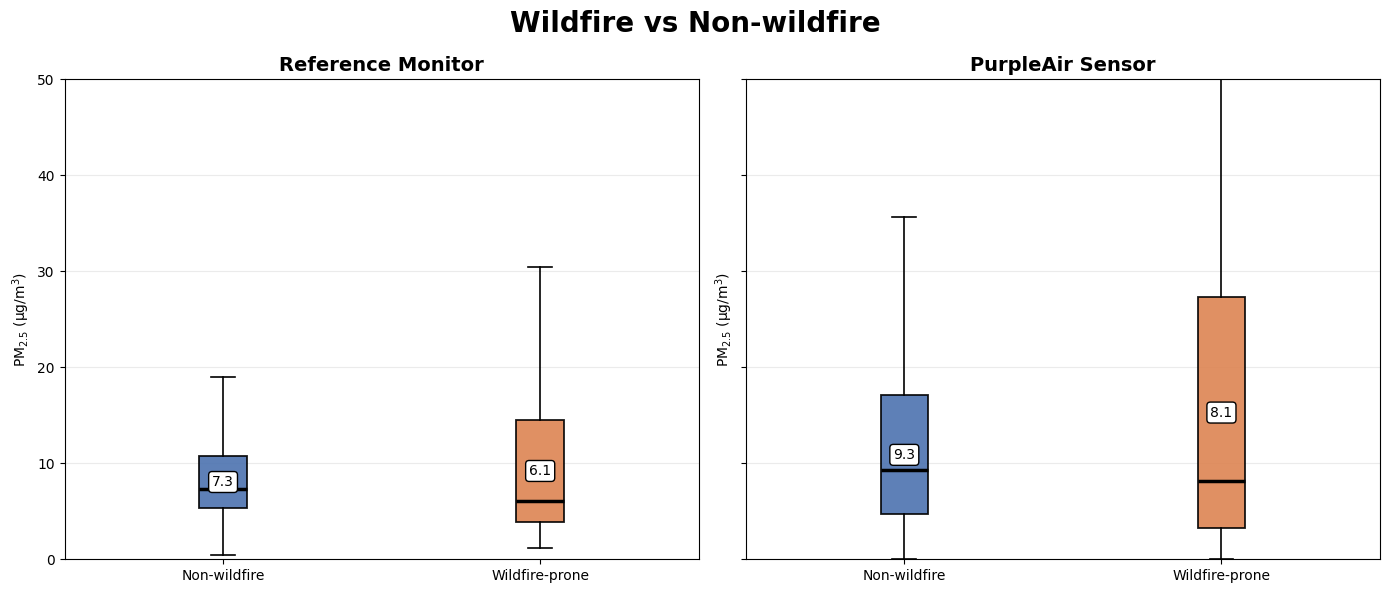

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------
# SETTINGS
# -----------------------------------
PLOT_MAX = 50

# Group colors
non_color = "#4C72B0"   # blue for Non-wildfire
wf_color  = "#DD8452"   # orange for Wildfire

non_wildfire_cities = ["Wilmington", "RTP"]
wildfire_cities = ["Bend", "Oakridge"]

# -----------------------------------
# PREP DATA
# df must already exist and contain: City, ref, PA_val
# -----------------------------------
df = df.copy()

df["ref"] = pd.to_numeric(df["ref"], errors="coerce")
df["PA_val"] = pd.to_numeric(df["PA_val"], errors="coerce")

# create group column safely
df["Group"] = "Unknown"
df.loc[df["City"].isin(non_wildfire_cities), "Group"] = "Non-wildfire"
df.loc[df["City"].isin(wildfire_cities), "Group"] = "Wildfire-prone"

# keep only valid rows
df_plot = df[df["Group"].isin(["Non-wildfire", "Wildfire-prone"])].dropna(subset=["ref", "PA_val"])

# -----------------------------------
# HELPER: grouped values
# -----------------------------------
def grouped_vals(d, col):
    non_vals = d.loc[d["Group"] == "Non-wildfire", col].values
    wf_vals  = d.loc[d["Group"] == "Wildfire-prone", col].values
    return [non_vals, wf_vals]

# -----------------------------------
# HELPER: one panel
# -----------------------------------
def boxplot_panel(ax, vals, title):
    bp = ax.boxplot(
        vals,
        labels=["Non-wildfire", "Wildfire-prone"],
        patch_artist=True,
        showfliers=False,
        whis=1.5
    )

    # color boxes
    bp["boxes"][0].set_facecolor(non_color)
    bp["boxes"][1].set_facecolor(wf_color)

    for box in bp["boxes"]:
        box.set_edgecolor("black")
        box.set_linewidth(1.3)
        box.set_alpha(0.90)

    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(2.5)

    for w in bp["whiskers"]:
        w.set_color("black")
        w.set_linewidth(1.2)

    for c in bp["caps"]:
        c.set_color("black")
        c.set_linewidth(1.2)

    # put median label at center of box
    for i, v in enumerate(vals, start=1):
        v = np.asarray(v)
        v = v[~np.isnan(v)]
        if len(v) == 0:
            continue

        med = float(np.median(v))
        q1 = float(np.percentile(v, 25))
        q3 = float(np.percentile(v, 75))
        y_center = (q1 + q3) / 2

        ax.text(
            i, y_center, f"{med:.1f}",
            ha="center", va="center", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.25")
        )

    ax.set_ylim(0, PLOT_MAX)
    ax.set_ylabel("PM$_{2.5}$ (µg/m$^3$)")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

# -----------------------------------
# PLOT
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

boxplot_panel(axes[0], grouped_vals(df_plot, "ref"), "Reference Monitor")
boxplot_panel(axes[1], grouped_vals(df_plot, "PA_val"), "PurpleAir Sensor")

fig.suptitle("Wildfire vs Non-wildfire", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
data.groupby("City")["ref"].describe()

,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Bend,1758.0,29.714903,76.236525,1.500000,3.7,7.000000,16.475,485.000000
Oakridge,1865.0,36.440322,92.183845,1.200000,4.0,5.900000,12.500,717.100000
RTP,2350.0,8.463696,3.918525,0.446667,5.7,7.893333,10.700,39.872883
Wilmington,5705.0,8.450096,4.908262,0.800000,5.1,7.200000,10.800,34.700000


In [49]:
data.groupby("City")["ref"].median()

City
Bend          7.000000
Oakridge      5.900000
RTP           7.893333
Wilmington    7.200000
Name: ref, dtype: float64

In [50]:
print(df["City"].unique())

['Bend' 'Oakridge' 'Wilmington' 'RTP']


In [54]:
import numpy as np
import pandas as pd

# 1) Make sure required columns exist
needed = {"City", "ref", "PA_val"}
missing = needed - set(data.columns)
if missing:
    raise ValueError(f"Missing columns in data: {missing}. Found: {data.columns.tolist()}")

# 2) Define your groups (EDIT if you want different grouping)
non_wildfire_cities = ["Wilmington", "RTP"]
wildfire_cities     = ["Bend", "Oakridge"]

# 3) Create Group column (no dtype errors)
data["Group"] = None
data.loc[data["City"].isin(non_wildfire_cities), "Group"] = "Non-wildfire"
data.loc[data["City"].isin(wildfire_cities), "Group"] = "Wildfire-prone"

# Keep only rows that got assigned a group
dfg = data.dropna(subset=["Group", "ref", "PA_val"]).copy()

# 4) Build summary table (use PA_val, not PA)
summary_table = pd.DataFrame({
    "Reference Median": dfg.groupby("Group")["ref"].median(),
    "PurpleAir Median": dfg.groupby("Group")["PA_val"].median(),
    "Reference Count":  dfg.groupby("Group")["ref"].count(),
    "PurpleAir Count":  dfg.groupby("Group")["PA_val"].count(),
}).round(2)

summary_table

,Reference Median,PurpleAir Median,Reference Count,PurpleAir Count
Group,,,,
Non-wildfire,7.3,9.33,8055,8055
Wildfire-prone,6.1,8.12,3623,3623


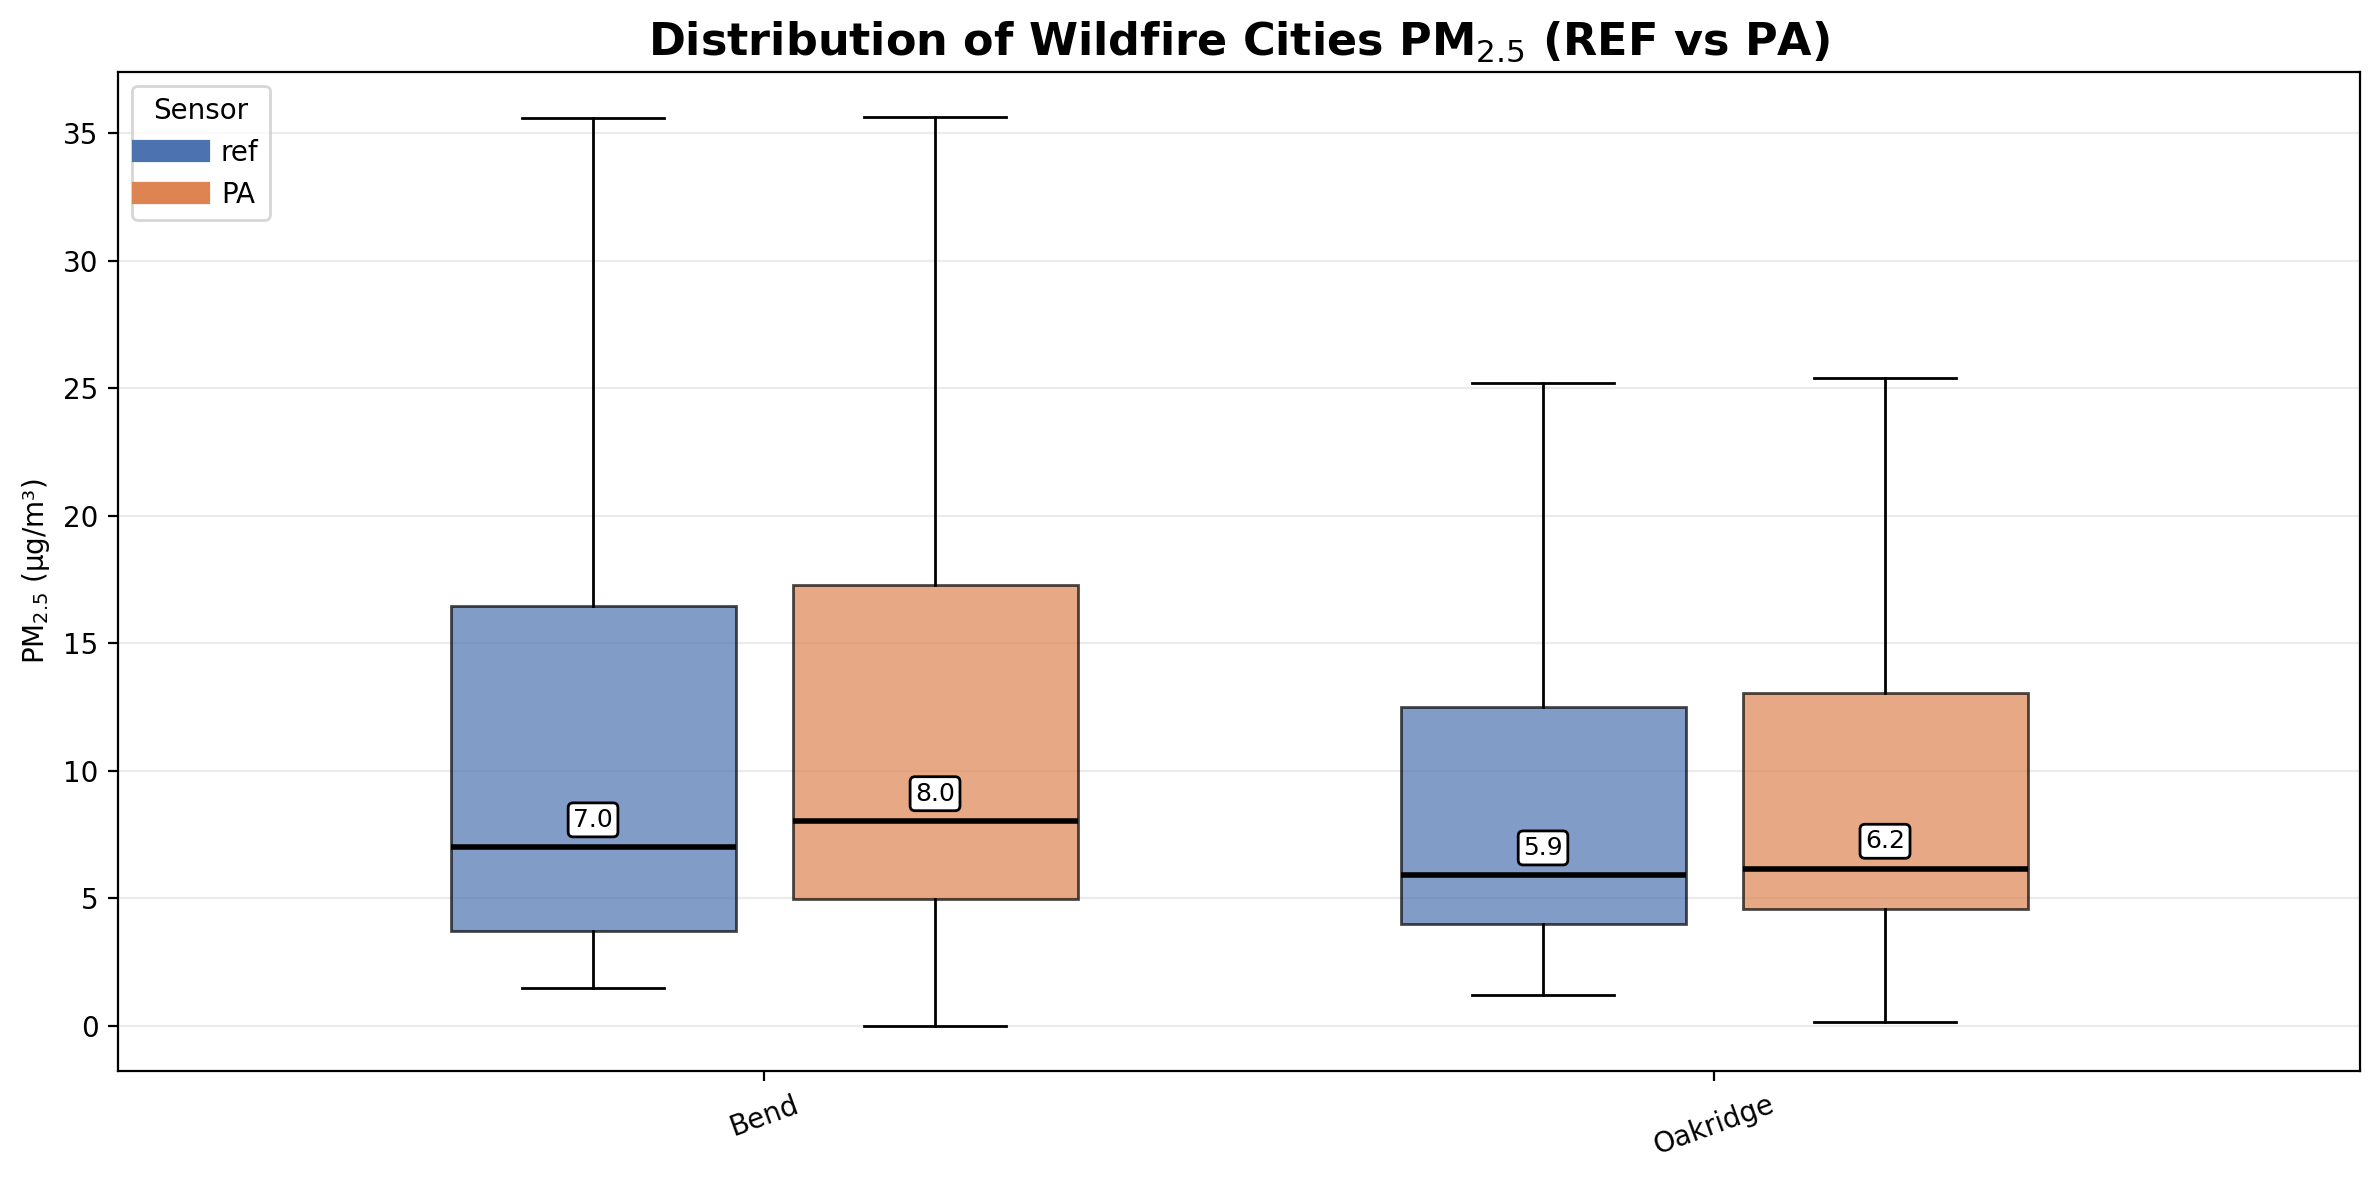

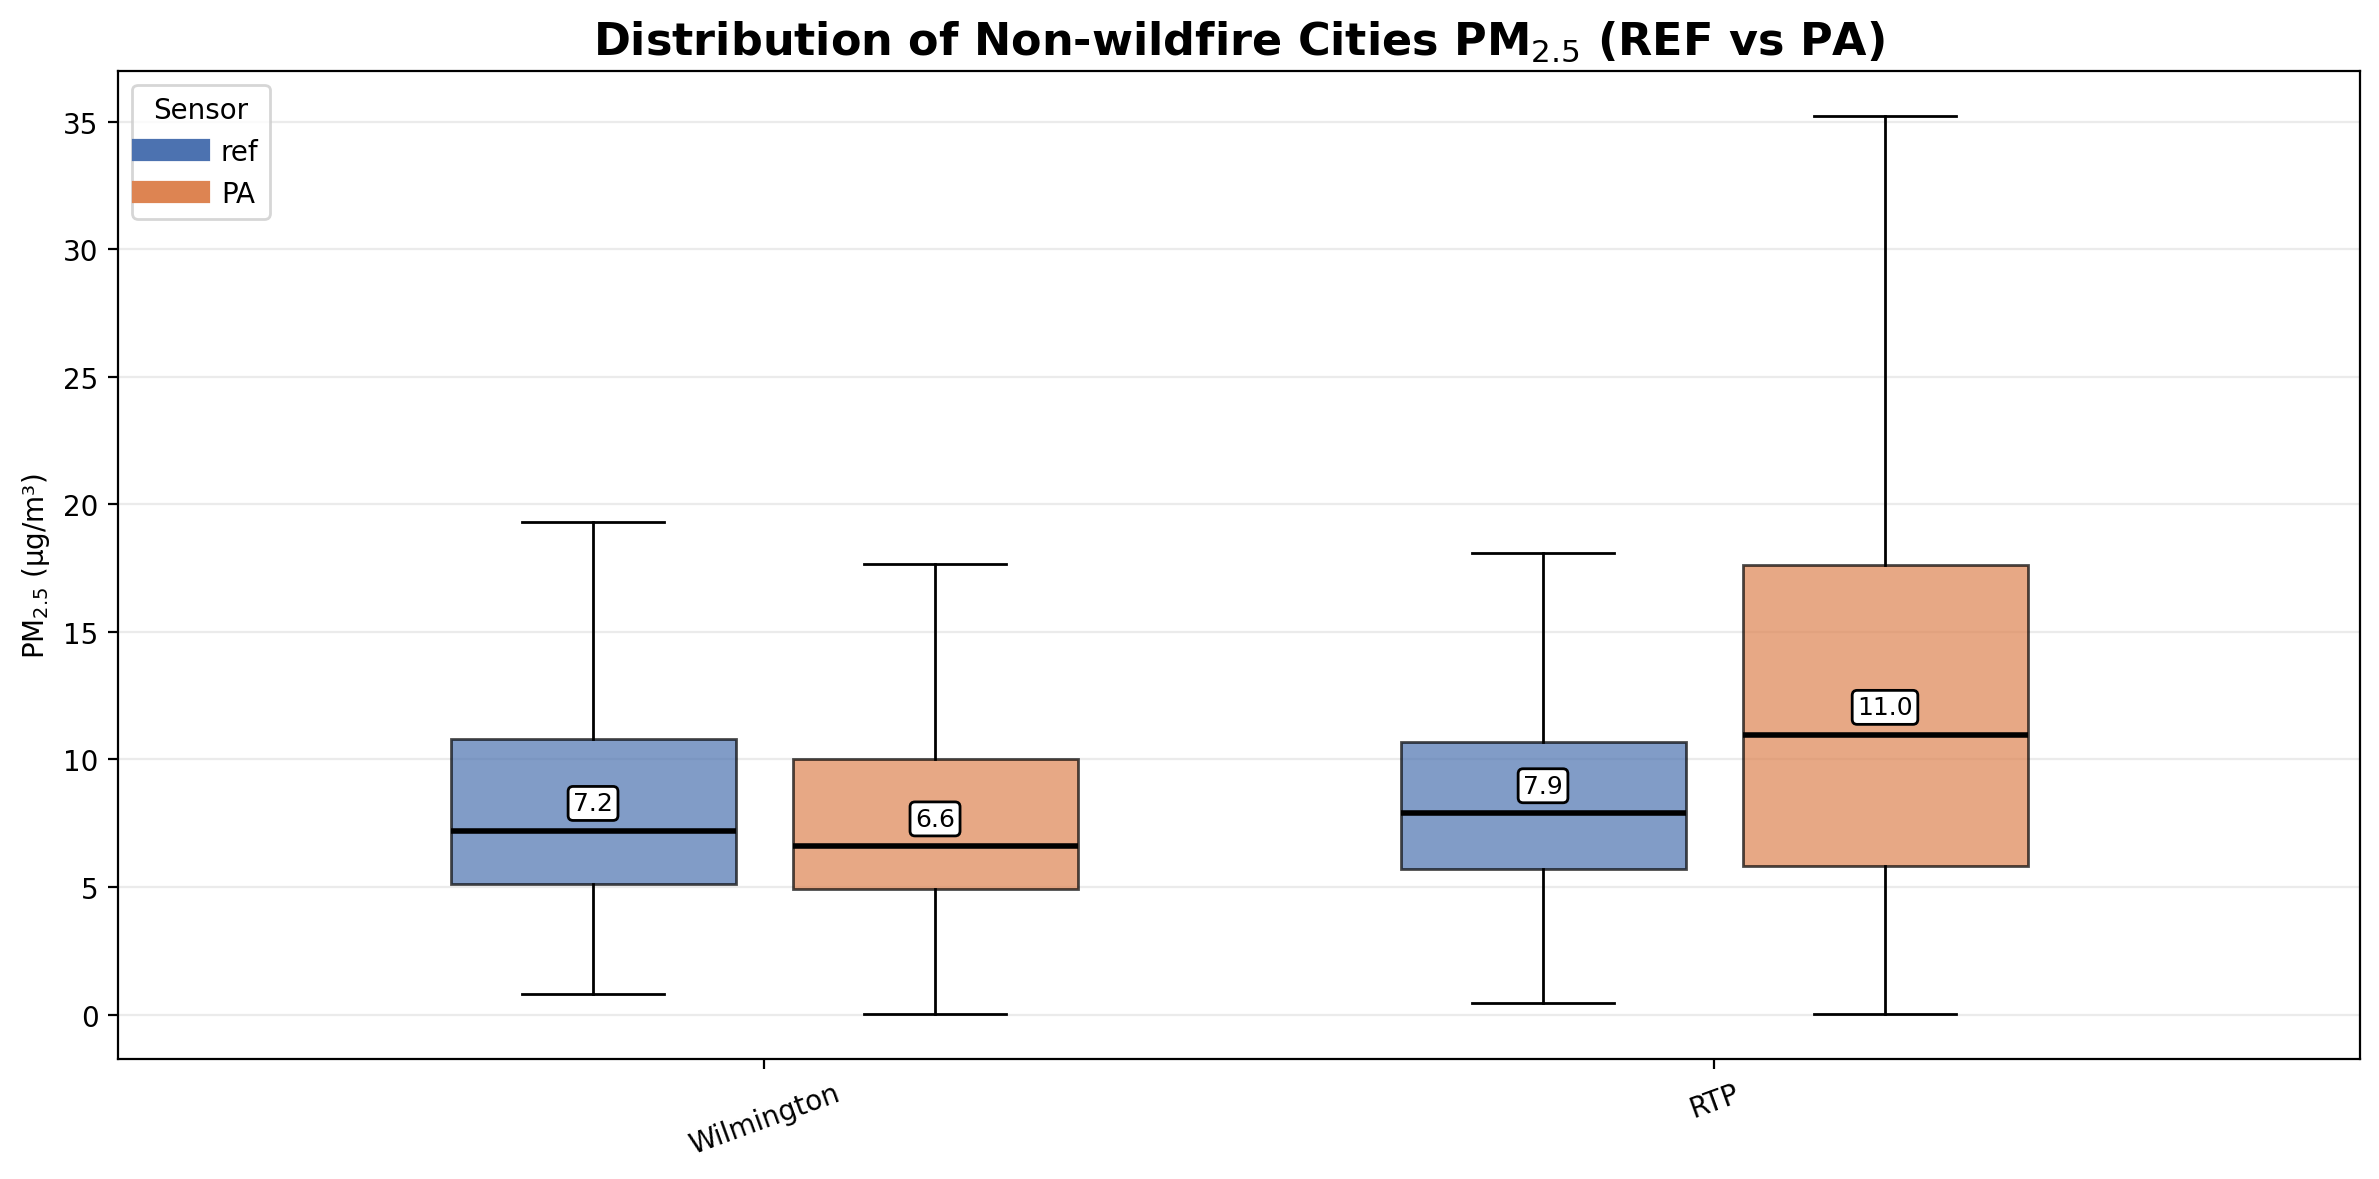

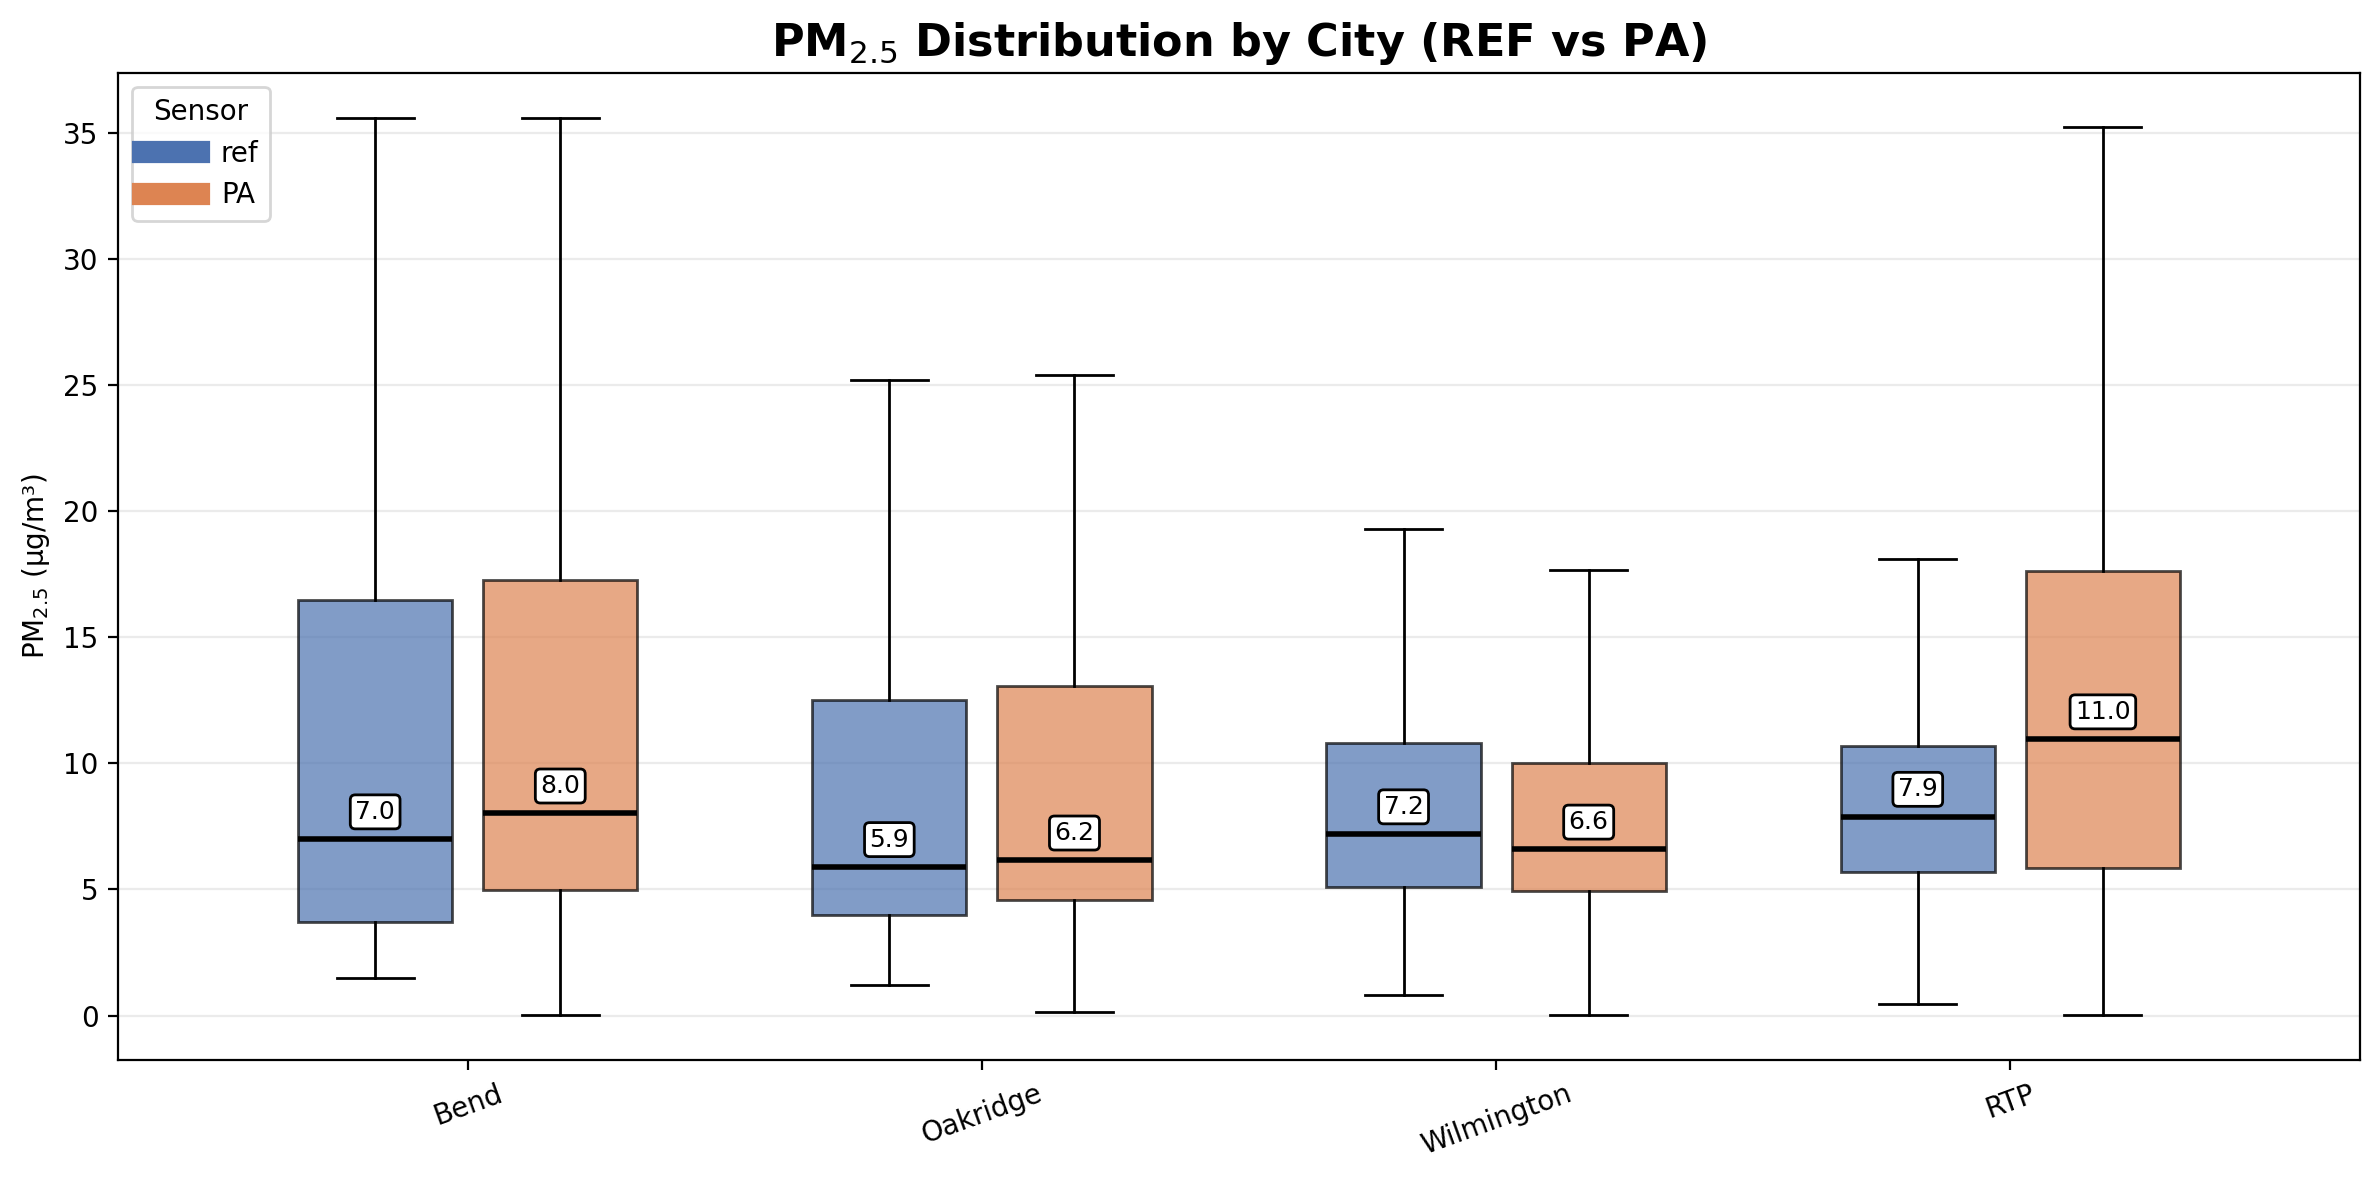

In [55]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Load + combine YOUR 4 city files (AFTER meteo merge) ----------
# Edit these paths ONLY if your cleaned files have different names
files = {
    "Bend": "cleaned_results/bend_pm_cleaned.csv",
    "Oakridge": "cleaned_results/oakridge_pm_cleaned.csv",
    "Wilmington": "cleaned_results/wilmington_pm_cleaned.csv",
    "RTP_1": "cleaned_results/rtp1_pm_cleaned.csv",
    "RTP_2": "cleaned_results/rtp2_pm_cleaned.csv",
}

missing = [p for p in files.values() if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"Missing these files:\n{missing}\n\nCheck cleaned_results/ filenames.")

dfs = []
for city, fp in files.items():
    d = pd.read_csv(fp)
    d.columns = d.columns.astype(str).str.strip()

    # Standardize City column
    if "City" not in d.columns and "city" in d.columns:
        d = d.rename(columns={"city": "City"})
    if "City" not in d.columns:
        d["City"] = city

    # Force correct city label (merge RTP_1 + RTP_2 into RTP)
    if city in ["RTP_1", "RTP_2"]:
        d["City"] = "RTP"
    else:
        d["City"] = city

    # Standardize REF column
    if "ref" not in d.columns:
        raise ValueError(f"{fp}: missing 'ref' column. Columns: {d.columns.tolist()}")

    # Standardize PA column (PA / adj / pa)
    if "PA" in d.columns:
        pa_col = "PA"
    elif "adj" in d.columns:
        pa_col = "adj"
    elif "pa" in d.columns:
        pa_col = "pa"
    else:
        raise ValueError(f"{fp}: missing PA column ('PA' or 'adj' or 'pa'). Columns: {d.columns.tolist()}")

    d["ref"] = pd.to_numeric(d["ref"], errors="coerce")
    d["PA"]  = pd.to_numeric(d[pa_col], errors="coerce")

    dfs.append(d[["City", "ref", "PA"]])

df = pd.concat(dfs, ignore_index=True)

# ---------- 2) Define wildfire vs non-wildfire groups (YOUR cities) ----------
wildfire_cities = {"Bend", "Oakridge"}
df["fire_group"] = np.where(df["City"].isin(wildfire_cities), "Wildfire", "Non-wildfire")

# ---------- 3) Clean PM2.5 columns ----------
df = df.dropna(subset=["ref", "PA"])
df = df[(df["ref"] >= 0) & (df["PA"] >= 0)]

# ---------- 4) Helper: grouped boxplot (REF vs PA) for a set of cities ----------
def grouped_sensor_boxplot(data, cities, title, out_png=None):
    fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

    positions_ref, positions_pa = [], []
    data_ref, data_pa = [], []

    for i, city in enumerate(cities, start=1):
        d = data[data["City"] == city]

        positions_ref.append(i - 0.18)
        positions_pa.append(i + 0.18)

        data_ref.append(d["ref"].dropna().values)
        data_pa.append(d["PA"].dropna().values)

    bp_ref = ax.boxplot(
        data_ref, positions=positions_ref, widths=0.30,
        patch_artist=True, showfliers=False
    )
    bp_pa = ax.boxplot(
        data_pa, positions=positions_pa, widths=0.30,
        patch_artist=True, showfliers=False
    )

    # Colors
    ref_color = "#4C72B0"
    pa_color  = "#DD8452"

    for b in bp_ref["boxes"]:
        b.set_facecolor(ref_color)
        b.set_edgecolor("black")
        b.set_alpha(0.7)

    for b in bp_pa["boxes"]:
        b.set_facecolor(pa_color)
        b.set_edgecolor("black")
        b.set_alpha(0.7)

    # Style lines
    for k in ["whiskers", "caps", "medians"]:
        for line in bp_ref[k]:
            line.set_color("black")
        for line in bp_pa[k]:
            line.set_color("black")

    for m in bp_ref["medians"]:
        m.set_linewidth(2)
    for m in bp_pa["medians"]:
        m.set_linewidth(2)

    # -------- ADD MEDIAN NUMBERS --------
    for vals, pos in zip(data_ref, positions_ref):
        if len(vals):
            med = np.median(vals)
            ax.text(
                pos,
                med + 0.8,
                f"{med:.1f}",
                ha="center",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white",
                          edgecolor="black")
            )

    for vals, pos in zip(data_pa, positions_pa):
        if len(vals):
            med = np.median(vals)
            ax.text(
                pos,
                med + 0.8,
                f"{med:.1f}",
                ha="center",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white",
                          edgecolor="black")
            )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel("PM$_{2.5}$ (µg/m³)")
    ax.set_xticks(range(1, len(cities) + 1))
    ax.set_xticklabels(cities, rotation=20)

    ax.plot([], [], color=ref_color, linewidth=8, label="ref")
    ax.plot([], [], color=pa_color, linewidth=8, label="PA")
    ax.legend(title="Sensor", loc="upper left")

    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300)

    plt.show()

# ---------- 5) Plot wildfire cities and non-wildfire cities separately ----------
wild_df = df[df["fire_group"] == "Wildfire"]
non_df  = df[df["fire_group"] == "Non-wildfire"]

wild_cities_order = ["Bend", "Oakridge"]
non_cities_order  = ["Wilmington", "RTP"]

grouped_sensor_boxplot(
    wild_df,
    wild_cities_order,
    "Distribution of Wildfire Cities PM$_{2.5}$ (REF vs PA)",
    "wildfire_cities_pm25_distribution.png",
)

grouped_sensor_boxplot(
    non_df,
    non_cities_order,
    "Distribution of Non-wildfire Cities PM$_{2.5}$ (REF vs PA)",
    "non_wildfire_cities_pm25_distribution.png",
)

# ---------- 6) One combined figure for all 4 cities ----------
grouped_sensor_boxplot(
    df,
    ["Bend", "Oakridge", "Wilmington", "RTP"],
    "PM$_{2.5}$ Distribution by City (REF vs PA)",
    "all_cities_pm25_distribution.png",
)

✅ Using these files:
  Bend: merged_results/Bend_PM_weather_hourly_EDA_ready.csv
  Oakridge: merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv
  Wilmington: merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv
  RTP: merged_results/RTP_PM_weather_hourly_EDA_ready.csv


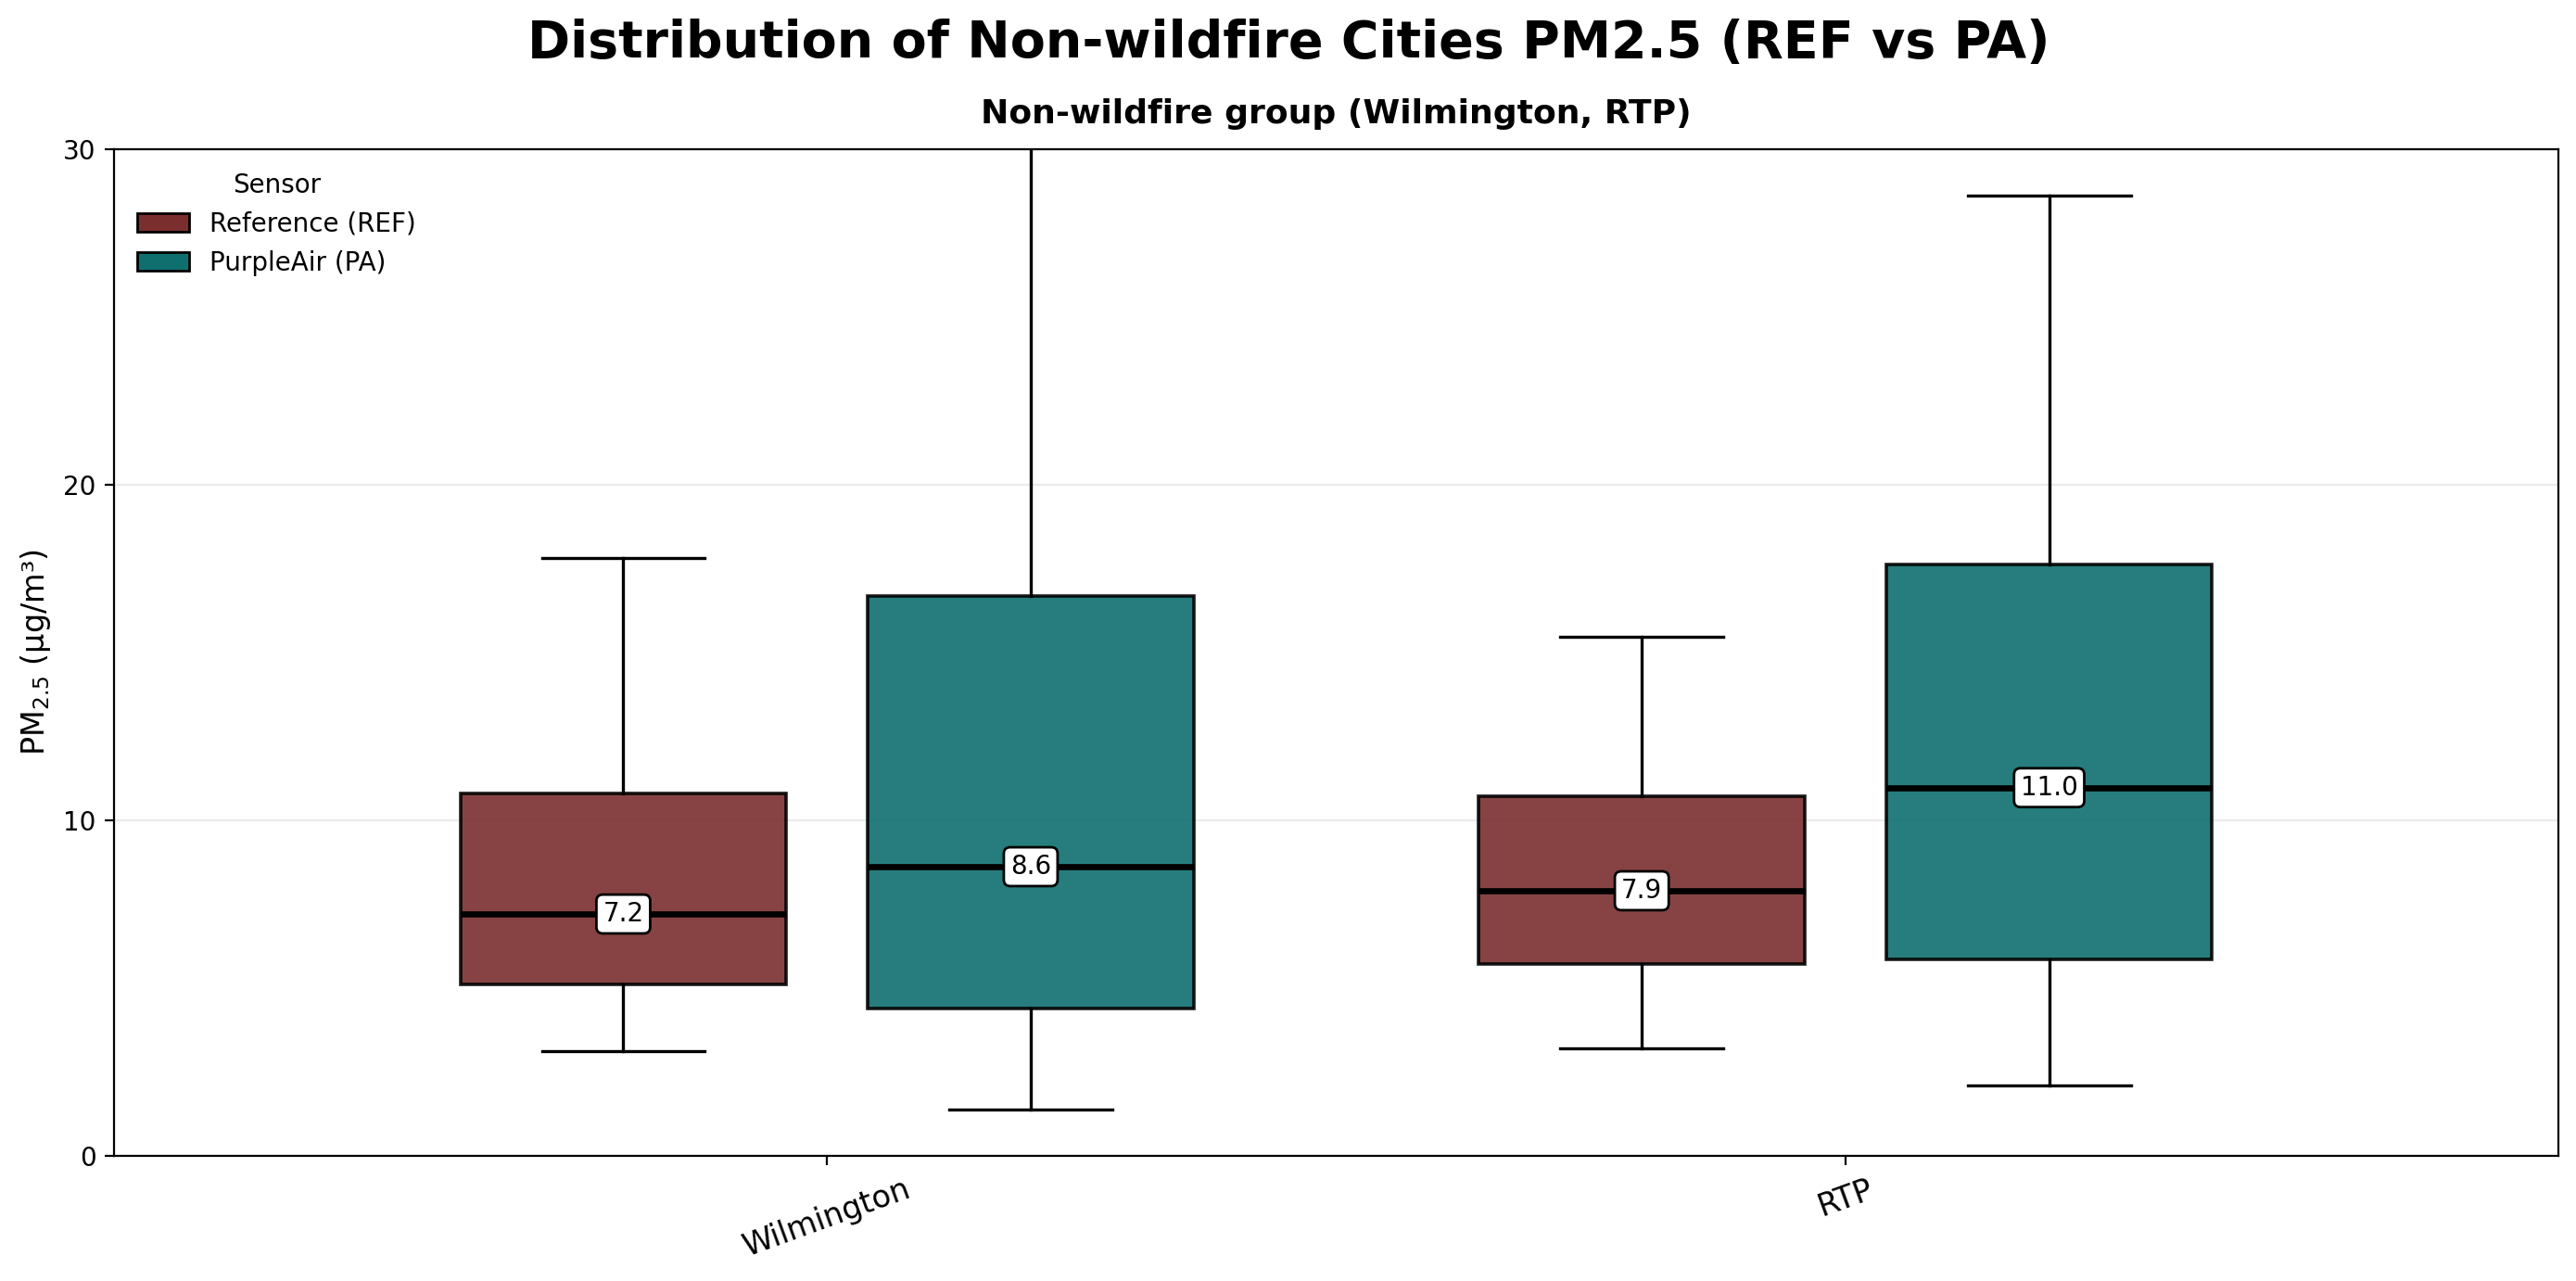

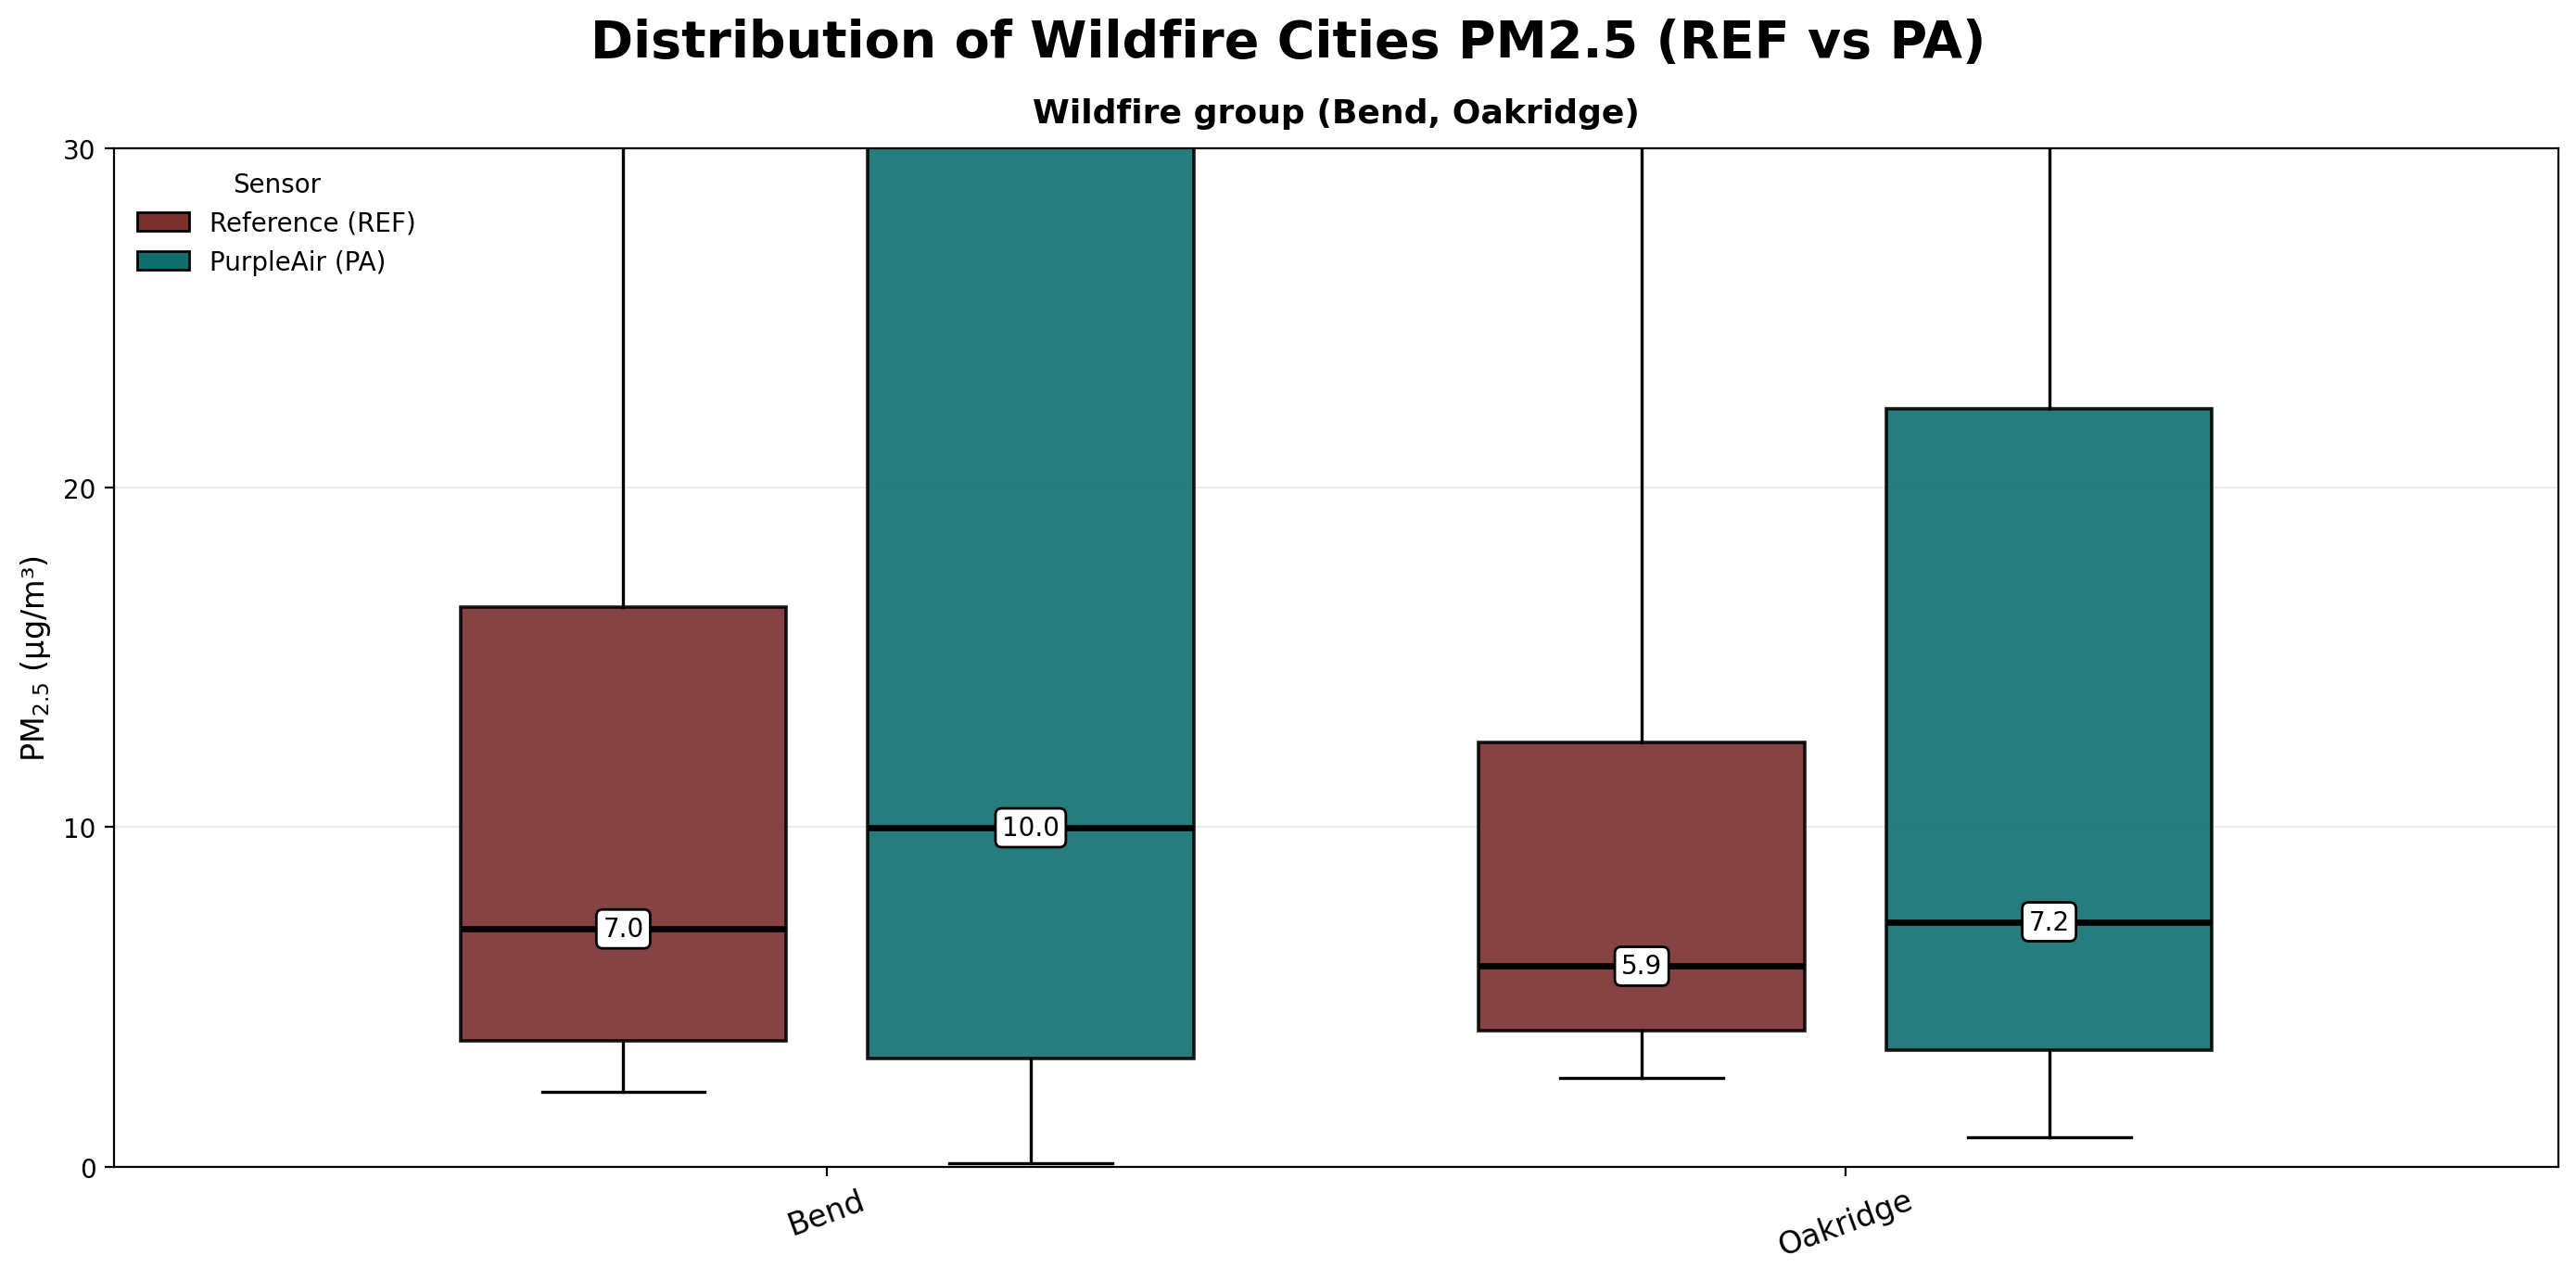

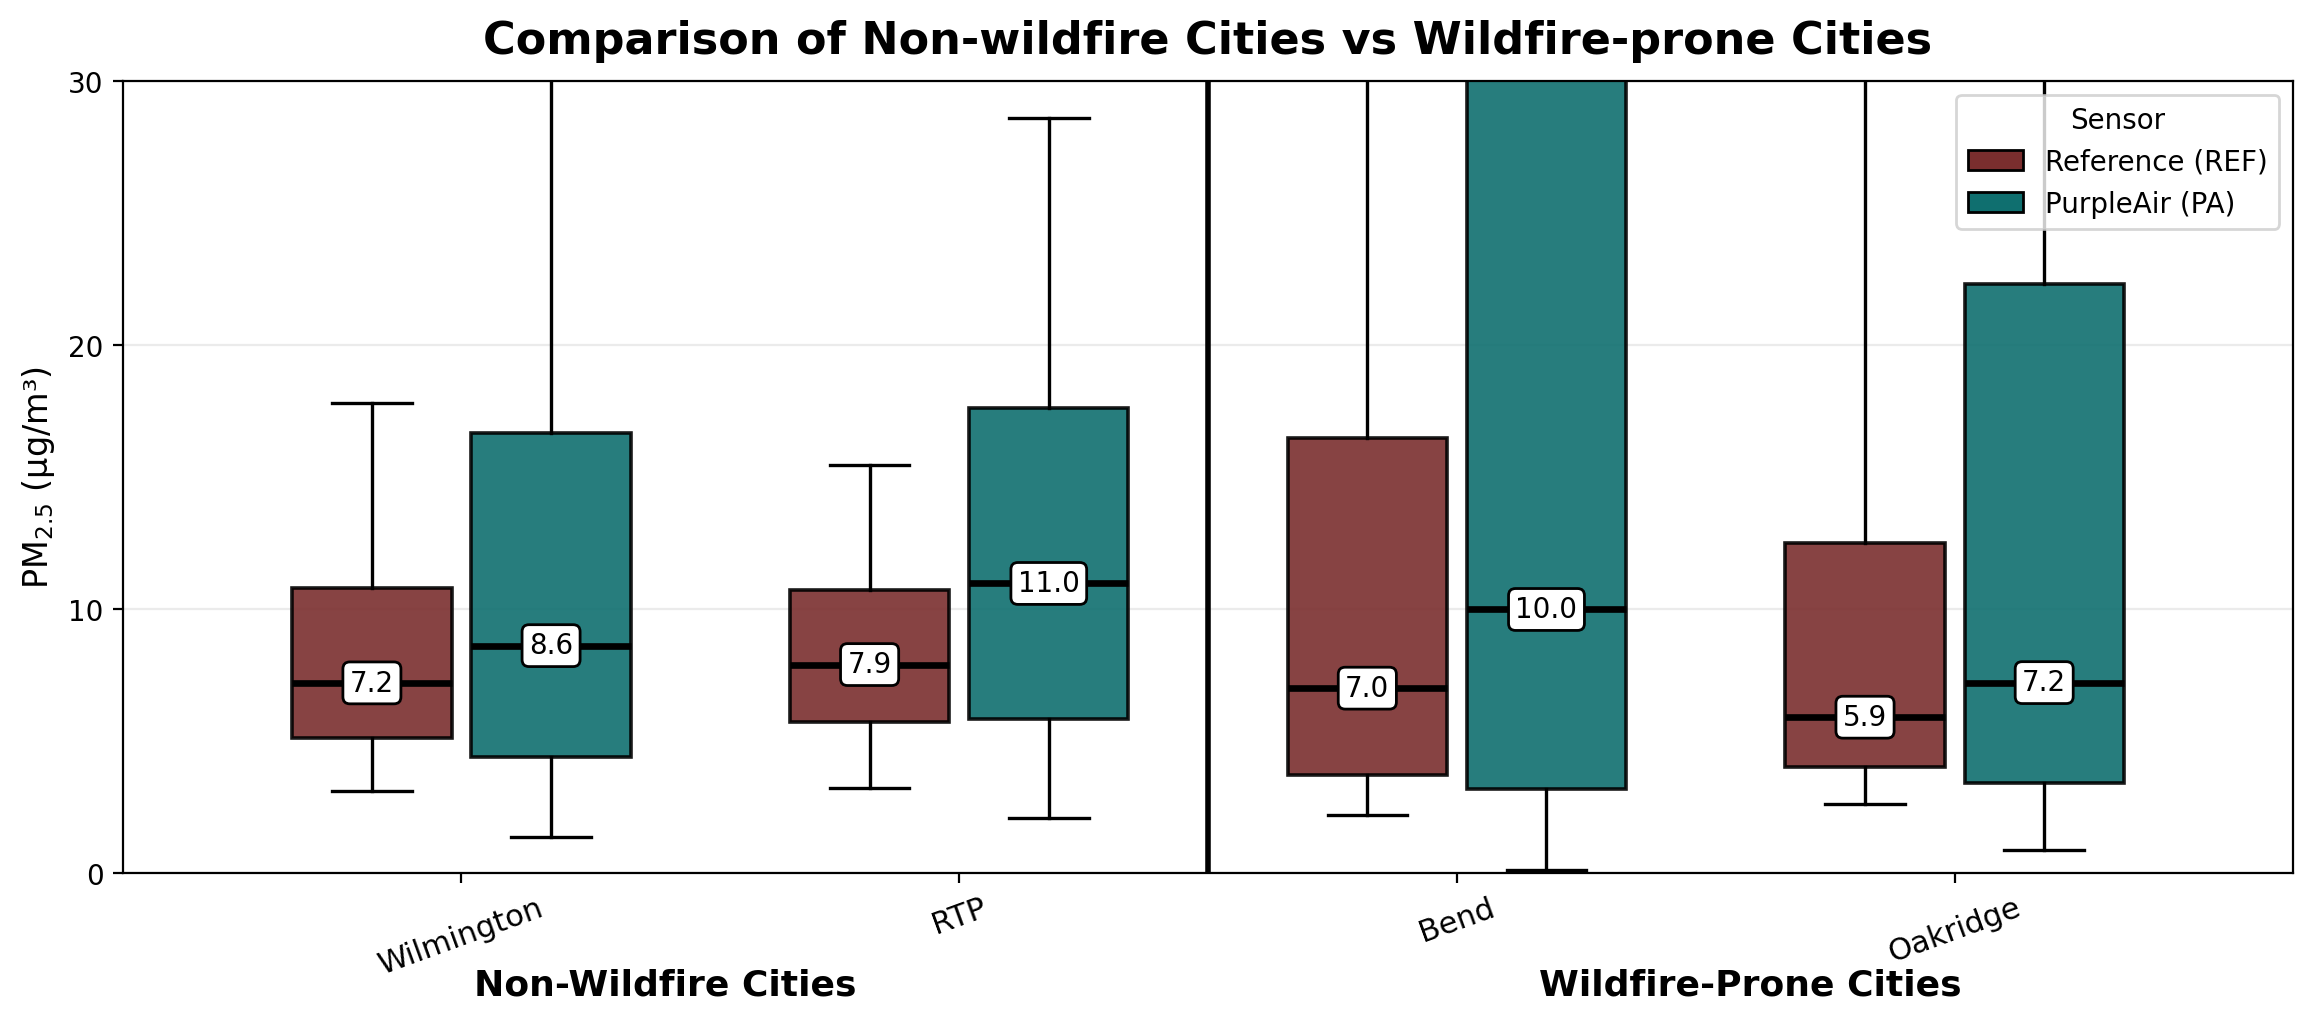


✅ Summary (Group-level):
         Group  Median_REF  Median_PA  Count_REF  Count_PA
  Non-wildfire         7.3   9.329333       8055      8055
Wildfire-prone         6.1   8.123667       3623      3623

✅ Summary (City-level):
            Median_REF  Median_PA  Count_REF  Count_PA
City                                                  
Wilmington    7.200000   8.610667       5705      5705
RTP           7.893333  10.965917       2350      2350
Bend          7.000000   9.980167       1758      1758
Oakridge      5.900000   7.210000       1865      1865


In [56]:
# CELL — FINAL (FULL CODE)
# ✅ Makes the 2 group plots (Non-wildfire + Wildfire) + the combined split plot
# ✅ Medians/tables match the SAME data used for plotting (NO clipping of values)
# ✅ Y-axis is just "zoomed" with set_ylim (so stats stay correct)
# ✅ Whiskers controlled with WHIS percentiles

import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# 0) SETTINGS
# -----------------------------
WILDFIRE = ["Bend", "Oakridge"]
NON_WILDFIRE = ["Wilmington", "RTP"]

# order for combined plot: non-wildfire first, then wildfire
CITY_ORDER_COMBINED = ["Wilmington", "RTP", "Bend", "Oakridge"]

# y-axis view only (does NOT change medians)
Y_MIN, Y_MAX = 0, 30

# whiskers as percentiles (controls those long whiskers)
# good default: (5, 95) or (5, 98)
WHIS = (5, 95)

# -----------------------------
# 1) AUTO-FIND CSVs
# Put your final (after merge / cleaned) CSVs in merged_results/ or cleaned_results/
# Filenames must contain city names like bend, oakridge, wilmington, rtp
# -----------------------------
search_dirs = ["merged_results", "cleaned_results", "."]
csv_candidates = []
for d in search_dirs:
    csv_candidates += glob.glob(os.path.join(d, "*.csv"))

if not csv_candidates:
    raise FileNotFoundError("No CSV files found in merged_results / cleaned_results / current folder.")

def prefer_eda_ready(paths):
    if not paths:
        return None
    scored = []
    for p in paths:
        n = os.path.basename(p).lower()
        score = 0
        for token in ["eda", "weather", "meteo", "merge", "hourly", "ready", "final", "clean"]:
            if token in n:
                score += 2
        scored.append((score, p))
    scored.sort(reverse=True)
    return scored[0][1]

def pick_city_files(candidates):
    def hits(keywords):
        out = []
        for f in candidates:
            name = os.path.basename(f).lower()
            if any(k in name for k in keywords):
                out.append(f)
        return out

    bend = prefer_eda_ready(hits(["bend"]))
    oak  = prefer_eda_ready(hits(["oakridge", "oak"]))
    wil  = prefer_eda_ready(hits(["wilmington", "wilm"]))
    rtp  = prefer_eda_ready(hits(["rtp"]))

    chosen = {"Bend": bend, "Oakridge": oak, "Wilmington": wil, "RTP": rtp}
    missing = [k for k, v in chosen.items() if v is None]
    if missing:
        raise FileNotFoundError(
            f"Could not auto-find files for: {missing}\n"
            f"Tip: Put 4 CSVs in merged_results/ or cleaned_results/ with city name in filename."
        )
    return chosen

files = pick_city_files(csv_candidates)

print("✅ Using these files:")
for city, fp in files.items():
    print(f"  {city}: {fp}")

# -----------------------------
# 2) LOAD + STANDARDIZE COLUMNS
# Required columns: ref and one of PA/pa/adj
# -----------------------------
def detect_pa_col(df):
    for c in ["PA", "pa", "adj", "PurpleAir", "purpleair"]:
        if c in df.columns:
            return c
    return None

dfs = []
for city, fp in files.items():
    df = pd.read_csv(fp)
    df.columns = df.columns.astype(str).str.strip()

    if "ref" not in df.columns:
        raise ValueError(f"'ref' column not found in {fp}. Columns: {df.columns.tolist()}")

    pa_col = detect_pa_col(df)
    if pa_col is None:
        raise ValueError(f"No PA column found in {fp}. Expected PA/pa/adj. Columns: {df.columns.tolist()}")

    df["City"] = city
    df["ref"] = pd.to_numeric(df["ref"], errors="coerce")
    df["PA_val"] = pd.to_numeric(df[pa_col], errors="coerce")

    dfs.append(df[["City", "ref", "PA_val"]])

data = pd.concat(dfs, ignore_index=True)

# IMPORTANT:
# If you want REF and PA compared using the SAME timestamps only, keep paired rows:
# data = data.dropna(subset=["ref", "PA_val"])
# If you want each sensor to use all its own readings independently, use this:
# (most presentations use paired comparison, so I'll keep paired)
data = data.dropna(subset=["ref", "PA_val"])

# keep non-negative only (typical for PM2.5)
data = data[(data["ref"] >= 0) & (data["PA_val"] >= 0)]

data["Group"] = np.where(data["City"].isin(WILDFIRE), "Wildfire-prone", "Non-wildfire")

# -----------------------------
# 3) HELPERS (NO clipping of values!)
# -----------------------------
def vals_full(series):
    v = pd.to_numeric(series, errors="coerce").dropna().values
    v = v[v >= 0]
    return v

ref_color = "#7A2E2E"   # maroon
pa_color  = "#0F6F6F"   # teal

legend_handles = [
    Patch(facecolor=ref_color, edgecolor="black", label="Reference (REF)"),
    Patch(facecolor=pa_color, edgecolor="black", label="PurpleAir (PA)")
]

def style_boxplot(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.3)
        box.set_alpha(0.90)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(2.4)
    for w in bp["whiskers"]:
        w.set_color("black")
        w.set_linewidth(1.2)
    for c in bp["caps"]:
        c.set_color("black")
        c.set_linewidth(1.2)

def add_median_label(ax, vals, x_pos):
    if len(vals) == 0:
        return
    med = float(np.median(vals))
    # keep label visible inside the zoomed axis range
    y = min(med, Y_MAX - 1)
    ax.text(
        x_pos, y,
        f"{med:.1f}",
        ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", linewidth=1.0)
    )

# -----------------------------
# 4) PLOT A: GROUP PLOT (Non-wildfire or Wildfire) — paired by city
# -----------------------------
def plot_group_by_city(cities, main_title, sub_title):
    ref_vals = [vals_full(data.loc[data["City"] == c, "ref"]) for c in cities]
    pa_vals  = [vals_full(data.loc[data["City"] == c, "PA_val"]) for c in cities]

    x = np.arange(len(cities))
    offset = 0.20
    width = 0.32

    fig, ax = plt.subplots(figsize=(14, 7), dpi=200)

    bp_ref = ax.boxplot(ref_vals, positions=x - offset, widths=width,
                        patch_artist=True, showfliers=False, whis=WHIS)
    bp_pa  = ax.boxplot(pa_vals,  positions=x + offset, widths=width,
                        patch_artist=True, showfliers=False, whis=WHIS)

    style_boxplot(bp_ref, ref_color)
    style_boxplot(bp_pa,  pa_color)

    for vals, pos in zip(ref_vals, x - offset):
        add_median_label(ax, vals, pos)
    for vals, pos in zip(pa_vals, x + offset):
        add_median_label(ax, vals, pos)

    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=20, fontsize=12)
    ax.set_ylabel("PM$_{2.5}$ (µg/m³)", fontsize=12)

    # zoom only (does NOT change stats)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_yticks(np.arange(Y_MIN, Y_MAX + 1, 10))
    ax.grid(axis="y", alpha=0.25)

    fig.suptitle(main_title, fontsize=20, fontweight="bold", y=0.98)
    ax.set_title(sub_title, fontsize=13, fontweight="bold", pad=10)

    ax.legend(handles=legend_handles, title="Sensor", loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5) PLOT B: COMBINED SPLIT PLOT (Non-wildfire vs Wildfire-prone) like your slide
# -----------------------------
def plot_combined_split():
    cities = CITY_ORDER_COMBINED
    ref_vals = [vals_full(data.loc[data["City"] == c, "ref"]) for c in cities]
    pa_vals  = [vals_full(data.loc[data["City"] == c, "PA_val"]) for c in cities]

    x = np.arange(len(cities))
    offset = 0.18
    width = 0.32

    fig, ax = plt.subplots(figsize=(14, 6), dpi=200)

    bp_ref = ax.boxplot(ref_vals, positions=x - offset, widths=width,
                        patch_artist=True, showfliers=False, whis=WHIS)
    bp_pa  = ax.boxplot(pa_vals,  positions=x + offset, widths=width,
                        patch_artist=True, showfliers=False, whis=WHIS)

    style_boxplot(bp_ref, ref_color)
    style_boxplot(bp_pa,  pa_color)

    for vals, pos in zip(ref_vals, x - offset):
        add_median_label(ax, vals, pos)
    for vals, pos in zip(pa_vals, x + offset):
        add_median_label(ax, vals, pos)

    # split line after 2 cities
    ax.axvline(1.5, color="black", linewidth=2)

    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=20, fontsize=11)
    ax.set_ylabel("PM$_{2.5}$ (µg/m³)", fontsize=12)

    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_yticks(np.arange(Y_MIN, Y_MAX + 1, 10))
    ax.grid(axis="y", alpha=0.25)

    # title at top
    ax.set_title("Comparison of Non-wildfire Cities vs Wildfire-prone Cities",
                 fontsize=16, fontweight="bold", pad=10)

    # bottom labels (like you asked)
    # place under the x-axis using axis coordinates
    ax.text(0.25, -0.12, "Non-Wildfire Cities", transform=ax.transAxes,
            ha="center", va="top", fontsize=13, fontweight="bold")
    ax.text(0.75, -0.12, "Wildfire-Prone Cities", transform=ax.transAxes,
            ha="center", va="top", fontsize=13, fontweight="bold")

    ax.legend(handles=legend_handles, title="Sensor", loc="upper right", frameon=True)

    # extra bottom room for those labels
    plt.subplots_adjust(bottom=0.22)
    plt.show()

# -----------------------------
# 6) RUN THE 3 PLOTS (matches your screenshots)
# -----------------------------
plot_group_by_city(
    NON_WILDFIRE,
    main_title="Distribution of Non-wildfire Cities PM2.5 (REF vs PA)",
    sub_title="Non-wildfire group (Wilmington, RTP)"
)

plot_group_by_city(
    WILDFIRE,
    main_title="Distribution of Wildfire Cities PM2.5 (REF vs PA)",
    sub_title="Wildfire group (Bend, Oakridge)"
)

plot_combined_split()

# -----------------------------
# 7) SUMMARY TABLE (counts + medians) — consistent with plots
# -----------------------------
summary = (data
           .assign(PA=data["PA_val"])
           .groupby(["Group"])
           .agg(
               Median_REF=("ref", "median"),
               Median_PA=("PA", "median"),
               Count_REF=("ref", "count"),
               Count_PA=("PA", "count")
           )
           .reset_index()
          )

print("\n✅ Summary (Group-level):")
print(summary.to_string(index=False))

# Optional: city-level table too
city_summary = (data
                .assign(PA=data["PA_val"])
                .groupby(["City"])
                .agg(
                    Median_REF=("ref", "median"),
                    Median_PA=("PA", "median"),
                    Count_REF=("ref", "count"),
                    Count_PA=("PA", "count")
                )
                .reindex(CITY_ORDER_COMBINED)
               )

print("\n✅ Summary (City-level):")
print(city_summary.to_string())

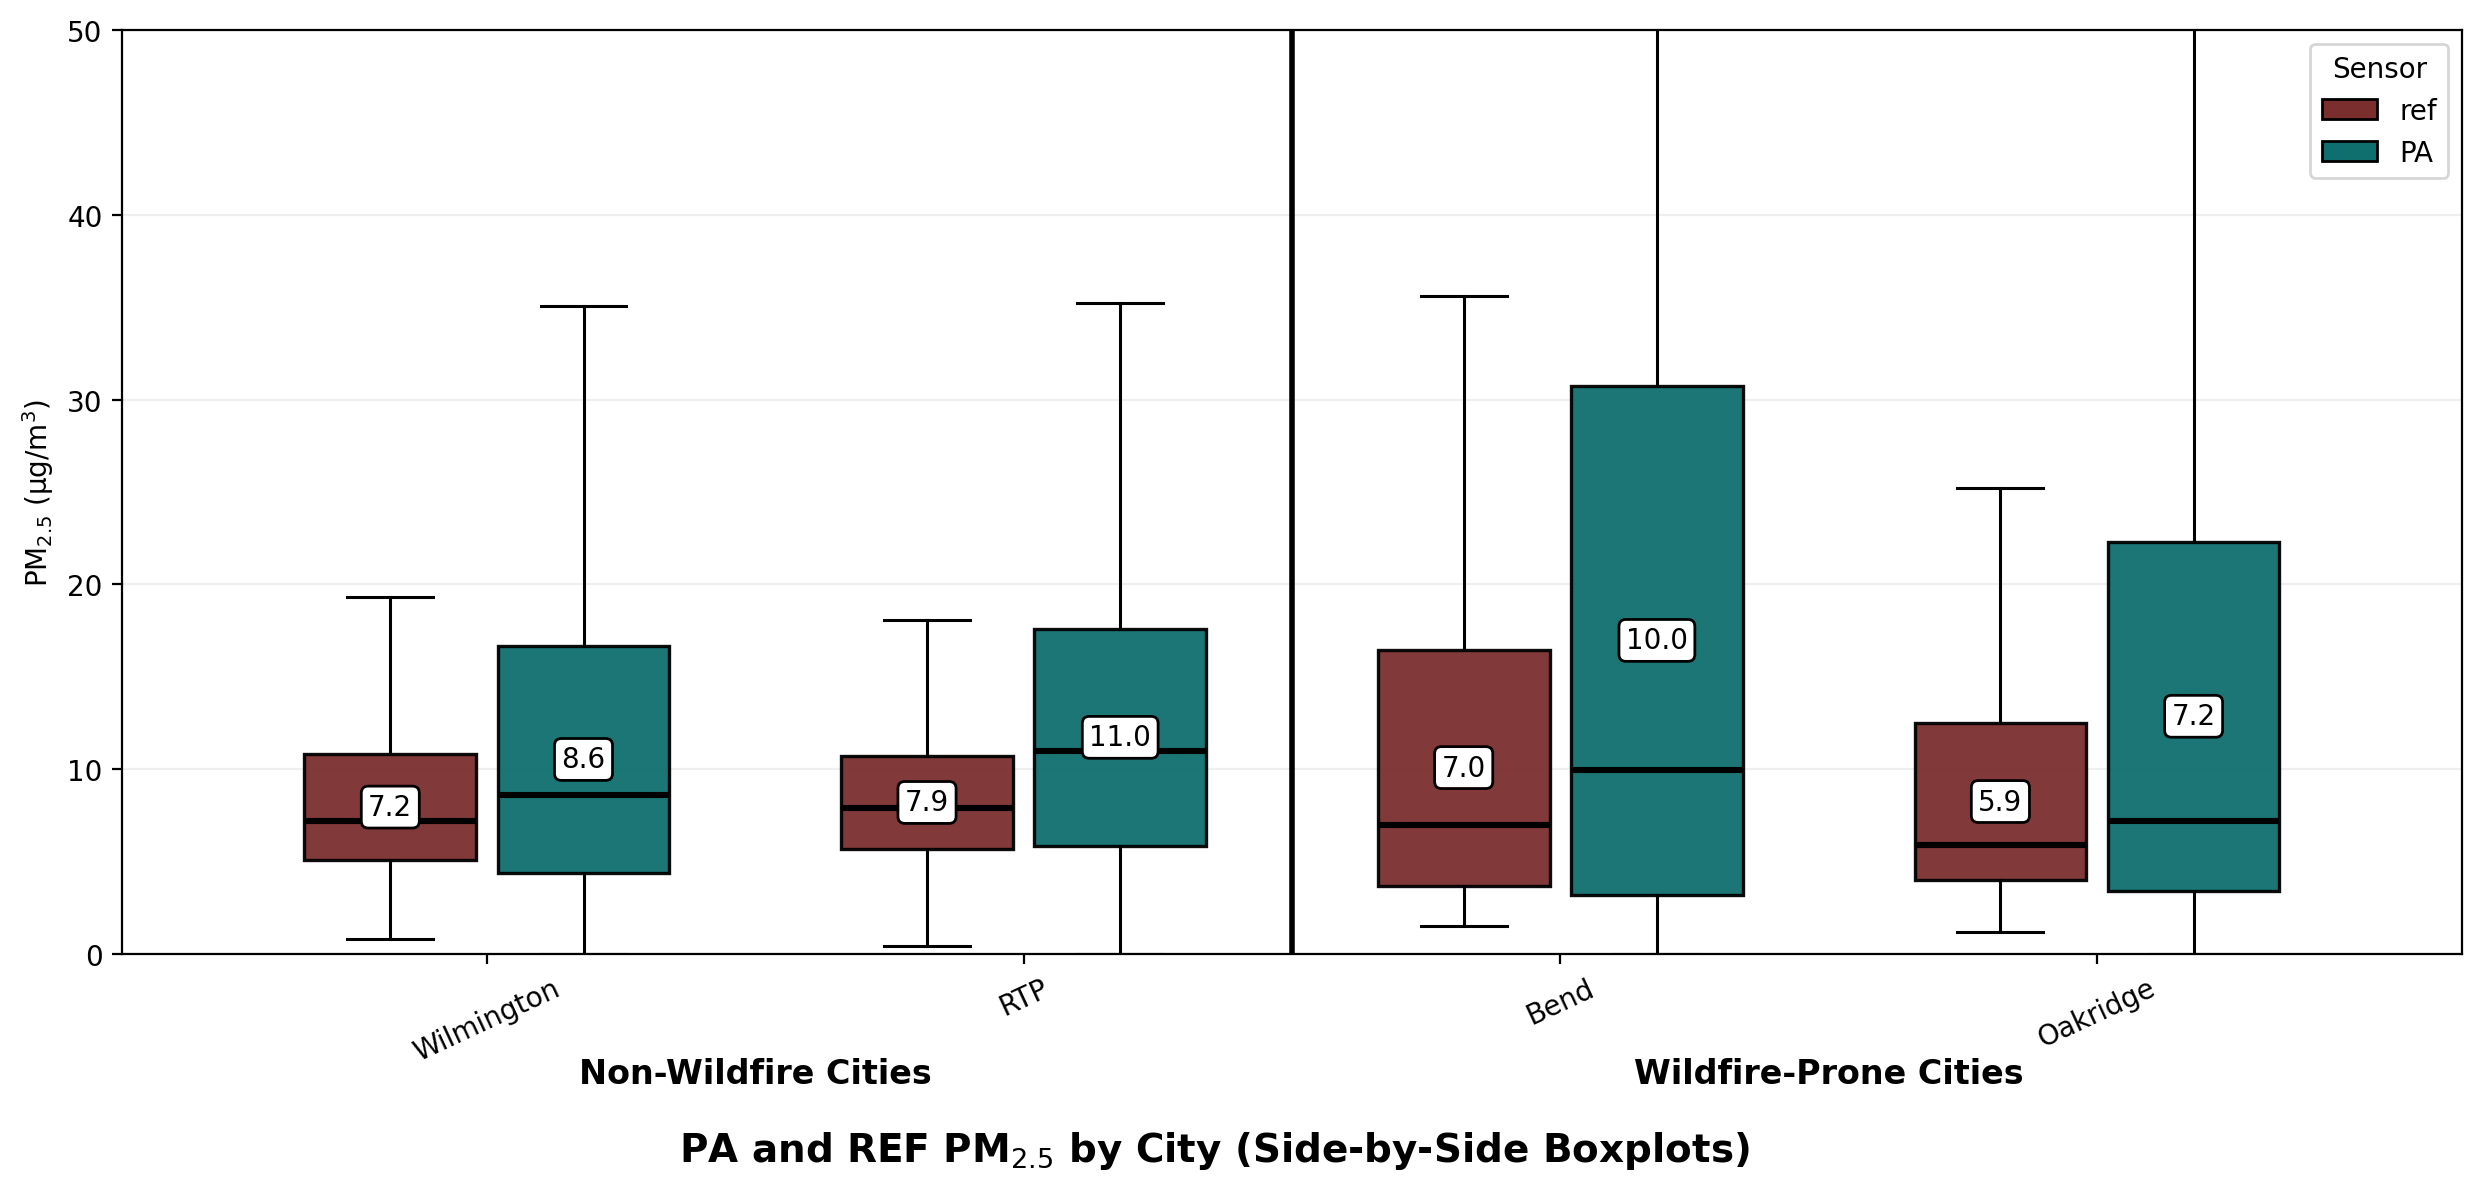

In [57]:
# --- ONE FIGURE (Friend style): title at bottom + group labels inside plot ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# REQUIRED: dataframe `data` with columns: City, ref, PA_val

# Colors (your exact palette)
ref_color = "#7A2E2E"   # maroon
pa_color  = "#0F6F6F"   # teal

# Order (Non-wildfire first, then Wildfire)
cities = ["Wilmington", "RTP", "Bend", "Oakridge"]

# Pull values
ref_vals = [data.loc[data["City"] == c, "ref"].dropna().to_numpy() for c in cities]
pa_vals  = [data.loc[data["City"] == c, "PA_val"].dropna().to_numpy() for c in cities]

x = np.arange(len(cities))
offset = 0.18
width = 0.32

# Friend-like canvas: more whitespace, plot centered
fig, ax = plt.subplots(figsize=(13, 7), dpi=200)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.22)

# Boxplots (same whisker style)
bp_ref = ax.boxplot(ref_vals, positions=x - offset, widths=width,
                    patch_artist=True, showfliers=False,whis=1.5)
bp_pa  = ax.boxplot(pa_vals,  positions=x + offset, widths=width,
                    patch_artist=True, showfliers=False, whis=1.5)

def style_bp(bp, facecolor):
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_edgecolor("black")
        box.set_linewidth(1.2)
        box.set_alpha(0.95)
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(2.2)
    for w in bp["whiskers"]:
        w.set_color("black")
        w.set_linewidth(1.1)
    for c in bp["caps"]:
        c.set_color("black")
        c.set_linewidth(1.1)

style_bp(bp_ref, ref_color)
style_bp(bp_pa,  pa_color)

# Median labels INSIDE the box (center of Q1-Q3)
def add_median_labels(vals_list, positions):
    for vals, pos in zip(vals_list, positions):
        vals = np.asarray(vals)
        vals = vals[~np.isnan(vals)]
        if vals.size == 0:
            continue
        med = float(np.median(vals))
        q1  = float(np.percentile(vals, 25))
        q3  = float(np.percentile(vals, 75))
        y_center = (q1 + q3) / 2.0
        ax.text(pos, y_center, f"{med:.1f}",
                ha="center", va="center", fontsize=10,
                bbox=dict(facecolor="white", edgecolor="black",
                          boxstyle="round,pad=0.25", linewidth=1.0))

add_median_labels(ref_vals, x - offset)
add_median_labels(pa_vals,  x + offset)

# Split line between the two groups
ax.axvline(1.5, color="black", linewidth=2)

# Axis labels / limits
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=25)
ax.set_ylabel("PM$_{2.5}$ (µg/m$^3$)")
ax.set_ylim(0, 50)
ax.grid(axis="y", alpha=0.20)

# Group labels (inside plot, top)
y_top = ax.get_ylim()[1]
# Bottom group labels
ax.text(0.5, -7, "Non-Wildfire Cities", ha="center", fontsize=12, fontweight="bold")
ax.text(2.5, -7, "Wildfire-Prone Cities", ha="center", fontsize=12, fontweight="bold")

legend = [
    Patch(facecolor=ref_color, edgecolor="black", label="ref"),
    Patch(facecolor=pa_color,  edgecolor="black", label="PA"),
]
ax.legend(handles=legend, title="Sensor", loc="upper right", frameon=True)

# Caption / title at bottom (friend style)
fig.text(0.5, 0.08, "PA and REF PM$_{2.5}$ by City (Side-by-Side Boxplots)",
         ha="center", va="center", fontsize=14, fontweight="bold")

plt.show()

# Optional save:
# fig.savefig("wildfire_split_friend_style.png", dpi=300, bbox_inches="tight")

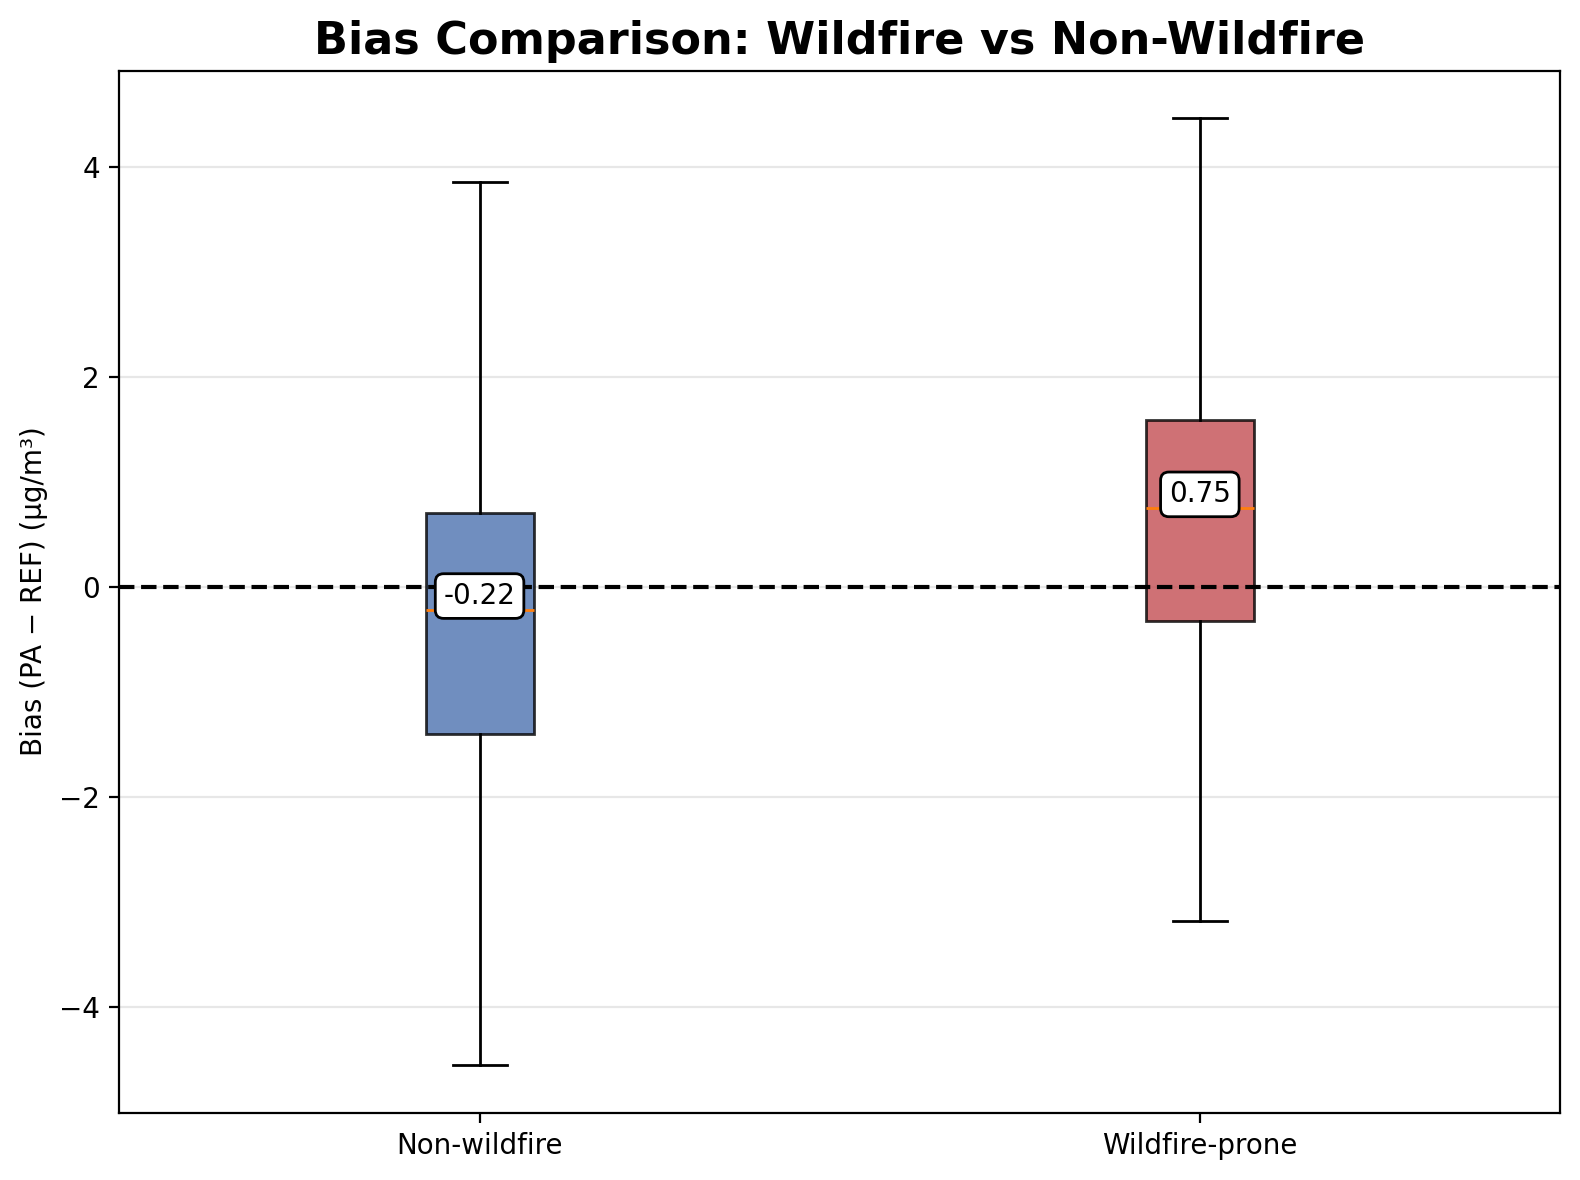

In [ ]:
# BIAS PLOT — Wildfire vs Non-Wildfire

import matplotlib.pyplot as plt
import numpy as np

pa_col = "PA_val" if "PA_val" in data.columns else ("PA" if "PA" in data.columns else "adj")

df = data[["ref", pa_col, "Group"]].dropna()
df["Bias"] = df[pa_col] - df["ref"]

plt.figure(figsize=(8,6), dpi=200)

groups = ["Non-wildfire", "Wildfire-prone"]
bias_data = [df[df["Group"] == g]["Bias"] for g in groups]

bp = plt.boxplot(bias_data, patch_artist=True, showfliers=False)

colors = ["#4C72B0", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for i, group in enumerate(groups, 1):
    median = np.median(df[df["Group"] == group]["Bias"])
    plt.text(i, median, f"{median:.2f}", 
             ha="center", va="bottom", fontsize=10,
             bbox=dict(boxstyle="round", facecolor="white"))

plt.axhline(0, linestyle="--", color="black", linewidth=1.5)

plt.xticks([1,2], groups)
plt.ylabel("Bias (PA − REF) (µg/m³)")
plt.title("Bias Comparison: Wildfire vs Non-Wildfire", fontsize=16, fontweight="bold")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

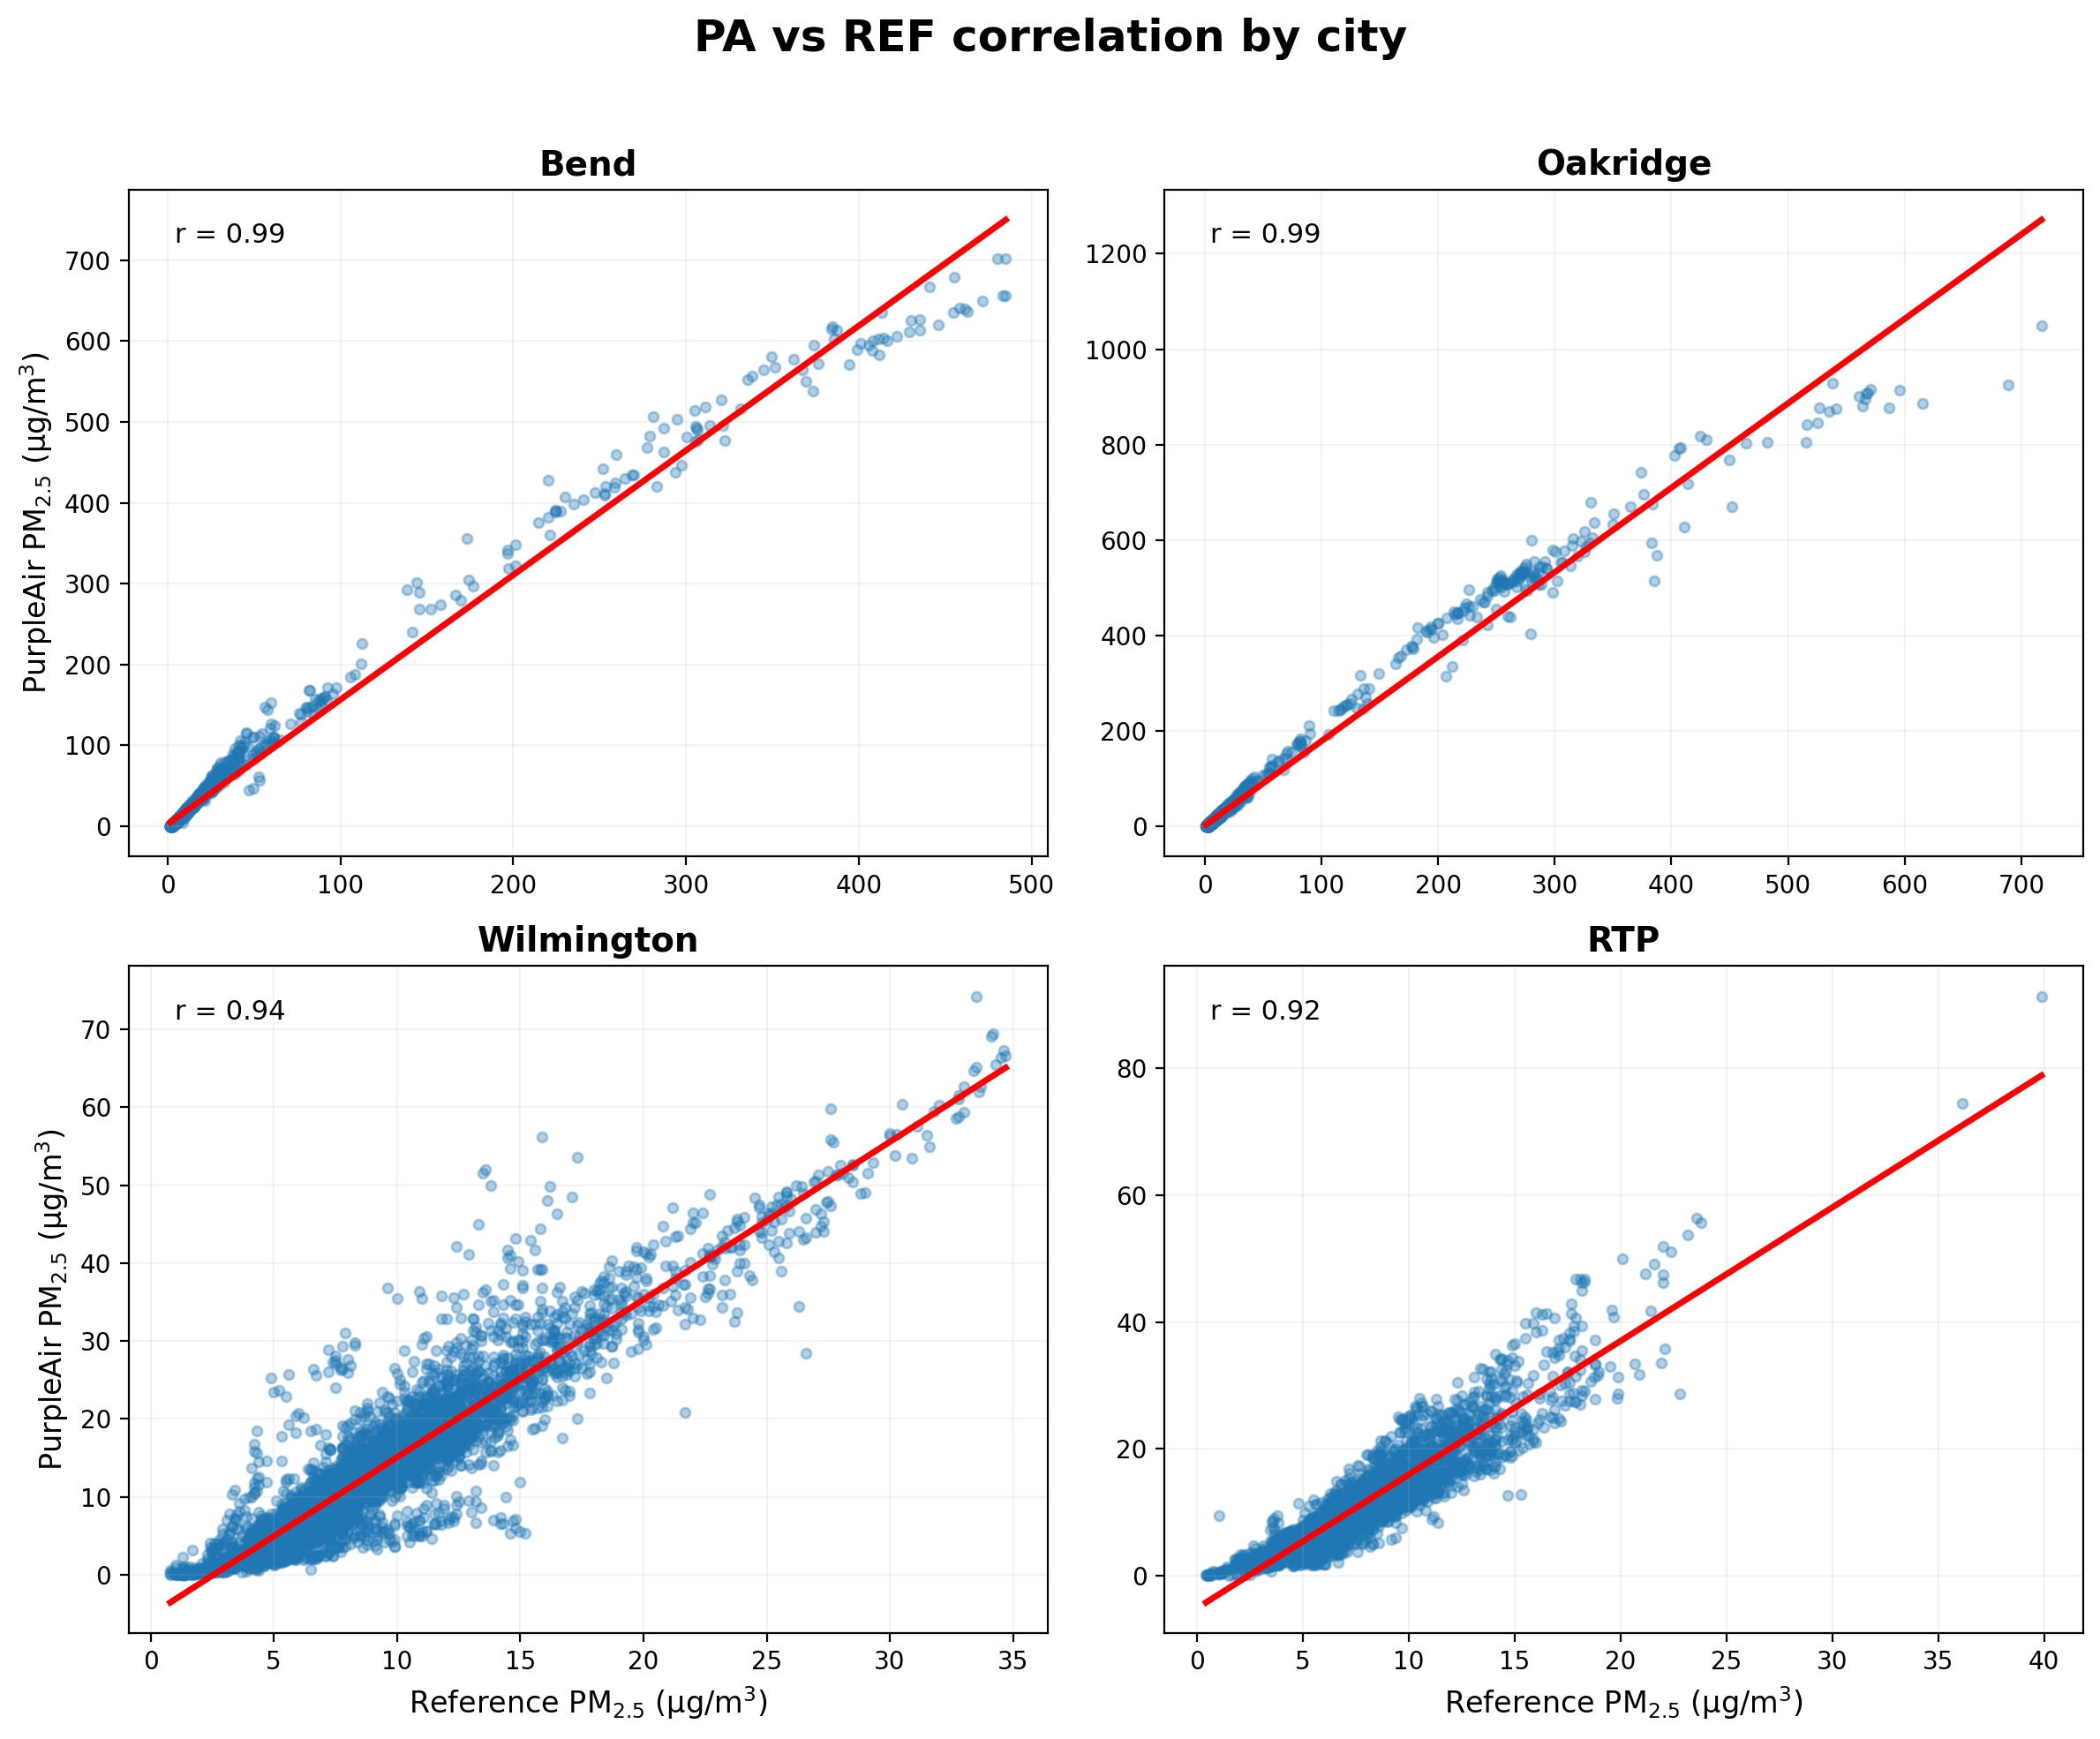

In [58]:
# SCATTER GRID (like your friend): PA vs REF with red fit line, one panel per city
# Needs: dataframe `data` with columns: City, ref, PA_val
# Cities: Bend, Oakridge, Wilmington, RTP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- settings
cities = ["Bend", "Oakridge", "Wilmington", "RTP"]
xcol = "ref"
ycol = "PA_val"

# optional: drop extreme outliers for cleaner plots (set to None to disable)
# example: clip to 0–500 ug/m3
CLIP_MAX = None  # e.g., 500

# ---- prep figure layout (2x2 for 4 cities)
n = len(cities)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10), dpi=200)
axes = np.array(axes).reshape(-1)

for i, city in enumerate(cities):
    ax = axes[i]
    dfc = data.loc[data["City"] == city, [xcol, ycol]].dropna()

    # keep non-negative
    dfc = dfc[(dfc[xcol] >= 0) & (dfc[ycol] >= 0)]

    # optional clipping for nicer view
    if CLIP_MAX is not None:
        dfc = dfc[(dfc[xcol] <= CLIP_MAX) & (dfc[ycol] <= CLIP_MAX)]

    x = dfc[xcol].to_numpy()
    y = dfc[ycol].to_numpy()

    # scatter
    ax.scatter(x, y, s=16, alpha=0.35)

    # red regression line (simple linear fit)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 200)
        ax.plot(xx, m * xx + b, color="red", linewidth=2.5)

        # correlation (optional text)
        r = np.corrcoef(x, y)[0, 1]
        ax.text(0.05, 0.92, f"r = {r:.2f}", transform=ax.transAxes, fontsize=11)

    ax.set_title(city, fontsize=14, fontweight="bold")
    ax.grid(alpha=0.15)

    # labels only on left/bottom like your friend's style
    if i % ncols == 0:
        ax.set_ylabel("PurpleAir PM$_{2.5}$ (µg/m$^3$)", fontsize=12)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("Reference PM$_{2.5}$ (µg/m$^3$)", fontsize=12)

# hide empty subplot if any
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("PA vs REF correlation by city", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Optional save:
# fig.savefig("pa_vs_ref_scatter_grid.png", dpi=300, bbox_inches="tight")

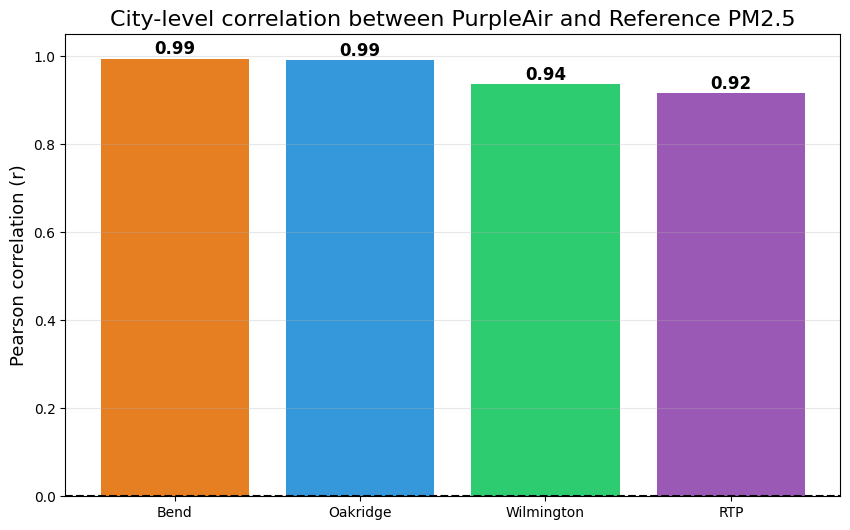

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cities you used
cities = ["Bend", "Oakridge", "Wilmington", "RTP"]

correlations = []

# Calculate correlation for each city
for city in cities:
    df_city = data[data["City"] == city][["ref", "PA_val"]].dropna()
    
    r = df_city["ref"].corr(df_city["PA_val"])
    correlations.append(r)

# Plot
plt.figure(figsize=(10,6))

colors = ["#E67E22","#3498DB","#2ECC71","#9B59B6"]

bars = plt.bar(cities, correlations, color=colors)

# Label correlation value on bars
for bar, r in zip(bars, correlations):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{r:.2f}",
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.ylim(0,1.05)

plt.ylabel("Pearson correlation (r)", fontsize=13)
plt.title("City-level correlation between PurpleAir and Reference PM2.5", fontsize=16)

plt.axhline(0, linestyle="--", color="black")

plt.grid(axis='y', alpha=0.3)

plt.show()

Wildfire Cities: ['Bend', 'Oakridge']
Non-Wildfire Cities: ['Wilmington', 'RTP']


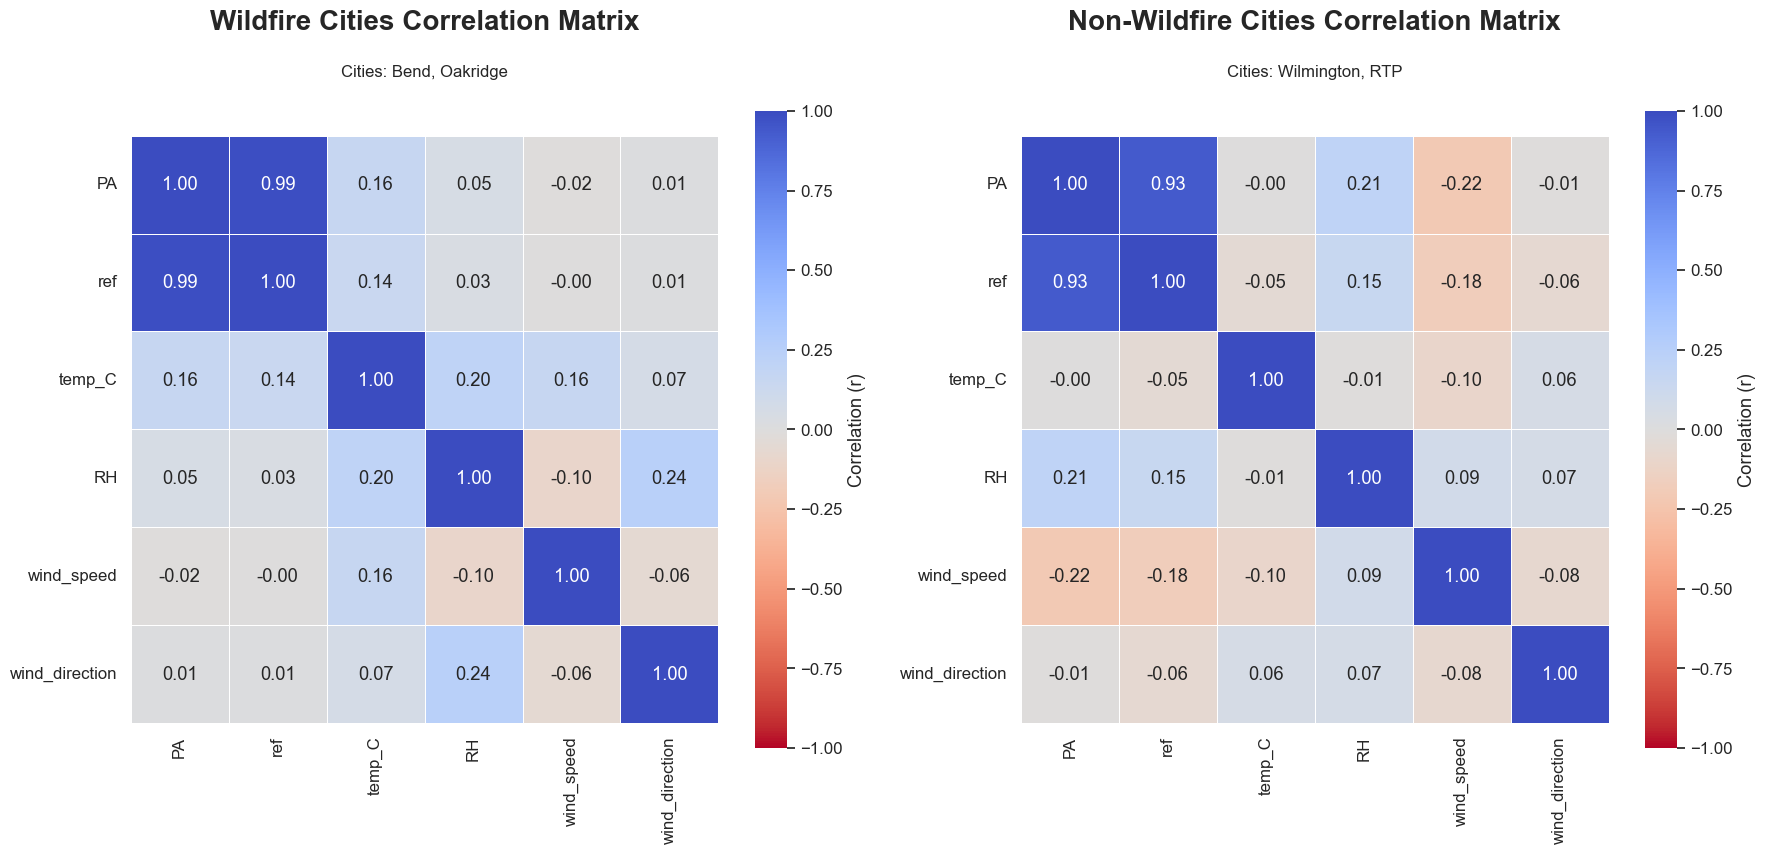

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="white", font_scale=1.1)

# -----------------------------
# Function to generate insights
# -----------------------------
def generate_insights(corr):
    pa_ref = corr.loc['PA', 'ref']
    temp_rh = corr.loc['temp_C', 'RH']
    wind_pa = corr.loc['wind_speed', 'PA']

    insights = [
        f"PA and REF PM2.5 show {'very strong' if abs(pa_ref) > 0.9 else 'strong'} agreement (r ≈ {pa_ref:.2f}).",
        "Meteorological variables exhibit weak linear correlations with PM₂.₅.",
        f"Temperature–RH relationship is {'moderately' if abs(temp_rh) > 0.2 else 'weakly'} negatively correlated (r ≈ {temp_rh:.2f}).",
        f"Wind speed suggests weak dispersion effects (r ≈ {wind_pa:.2f})."
    ]
    return insights


# -----------------------------
# Plot function
# -----------------------------
def plot_city_correlation(df, city_name):
    # use raw PA only
    variables = ['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']
    corr = df[variables].corr()

    insights = generate_insights(corr)

    fig = plt.figure(figsize=(14, 6))

    # Heatmap axis
    ax1 = plt.subplot2grid((1, 2), (0, 0))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm_r",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={'label': 'r'},
        ax=ax1
    )

    ax1.set_title(f"Correlation Matrix: {city_name}")

    # Insight panel
    ax2 = plt.subplot2grid((1, 2), (0, 1))
    ax2.axis('off')

    y = 0.9
    for text in insights:
        ax2.text(
            0.05,
            y,
            text,
            fontsize=14,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="#4f79a7",
                edgecolor="none",
                alpha=0.95
            ),
            color="white"
        )
        y -= 0.2

    plt.suptitle(f"{city_name} – Correlation Insights", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Load your datasets
# -----------------------------
bend = pd.read_csv("merged_results/Bend_PM_weather_hourly_EDA_ready.csv")
oakridge = pd.read_csv("merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv")
wilmington = pd.read_csv("merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv")
rtp = pd.read_csv("merged_results/RTP_PM_weather_hourly_EDA_ready.csv")


# -----------------------------
# Standardize column names
# -----------------------------
def prepare_df(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    # your files use lowercase names
    if 'pa' in df.columns and 'PA' not in df.columns:
        df['PA'] = pd.to_numeric(df['pa'], errors='coerce')
    else:
        df['PA'] = pd.to_numeric(df['PA'], errors='coerce')

    if 'rh' in df.columns and 'RH' not in df.columns:
        df['RH'] = pd.to_numeric(df['rh'], errors='coerce')
    else:
        df['RH'] = pd.to_numeric(df['RH'], errors='coerce')

    df['ref'] = pd.to_numeric(df['ref'], errors='coerce')
    df['temp_C'] = pd.to_numeric(df['temp_C'], errors='coerce')
    df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
    df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

    return df[['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']].dropna()


bend = prepare_df(bend)
oakridge = prepare_df(oakridge)
wilmington = prepare_df(wilmington)
rtp = prepare_df(rtp)


# -----------------------------
# Generate plots
# -----------------------------
plot_city_correlation(bend, "Bend")
plot_city_correlation(oakridge, "Oakridge")
plot_city_correlation(wilmington, "Wilmington")
plot_city_correlation(rtp, "RTP")

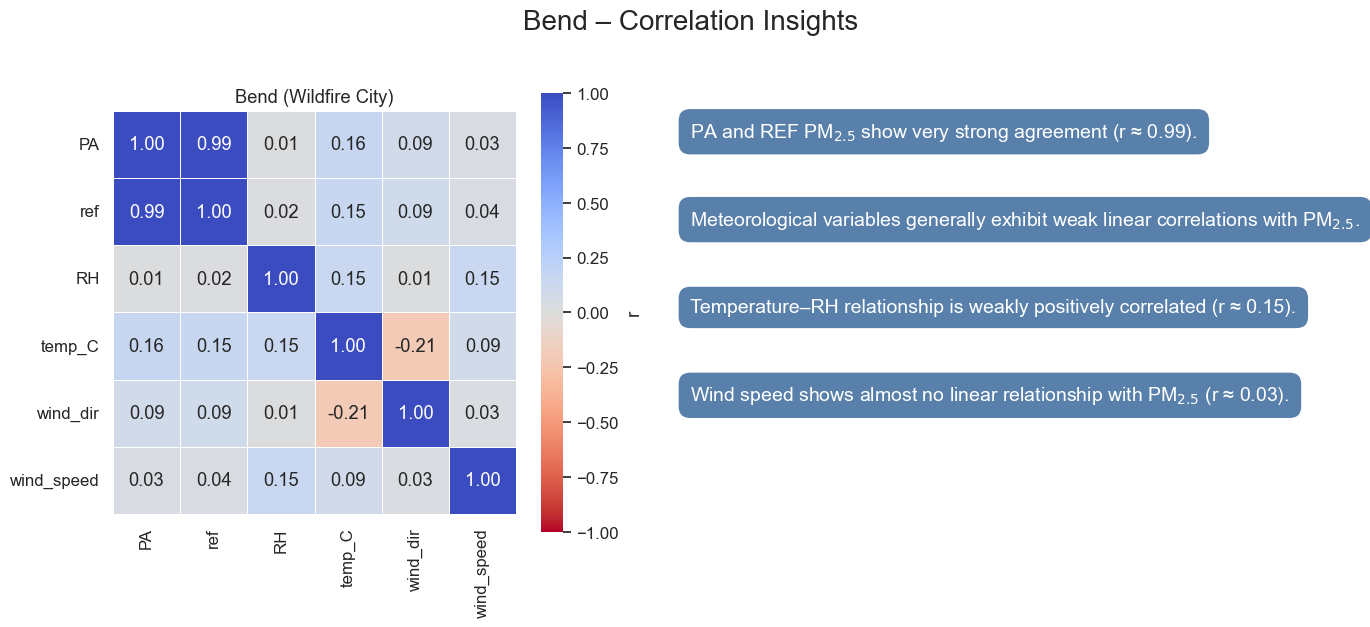

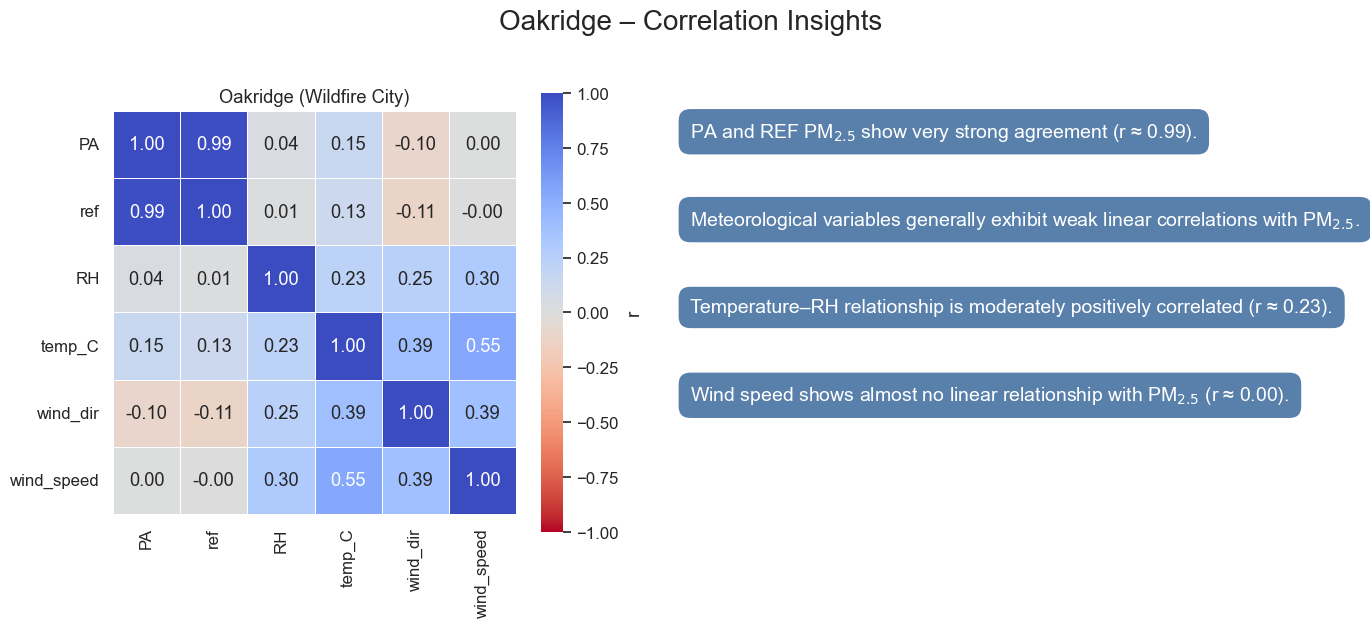

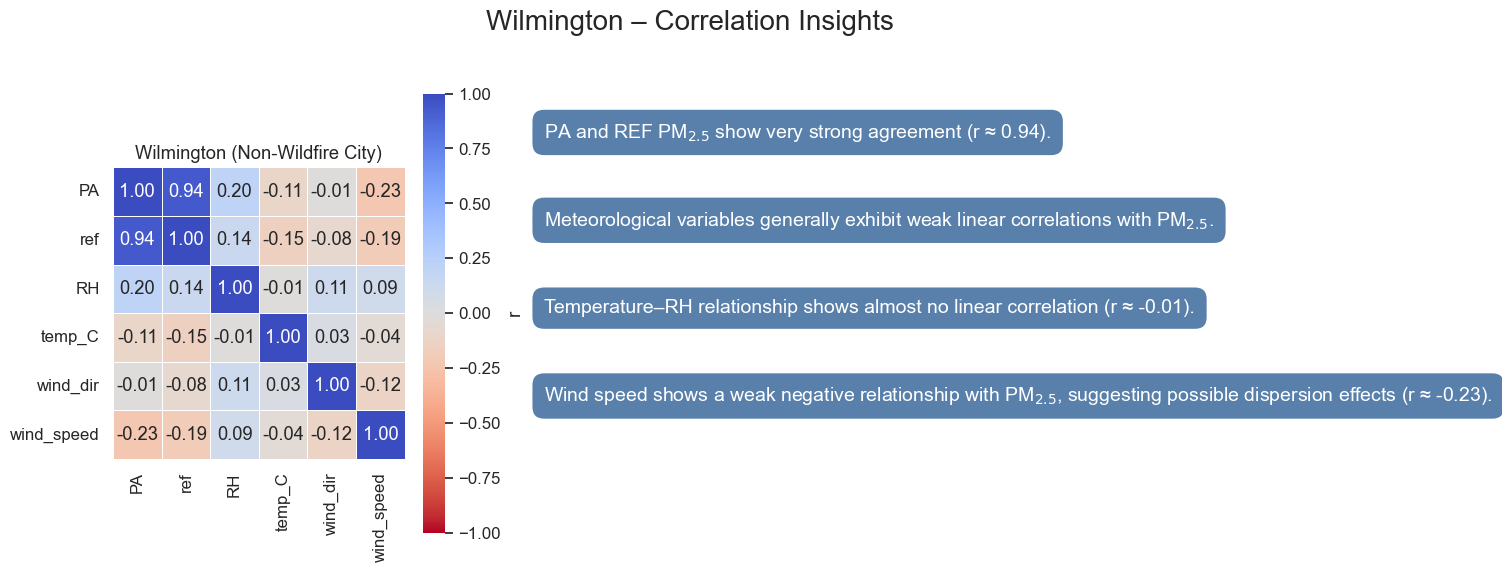

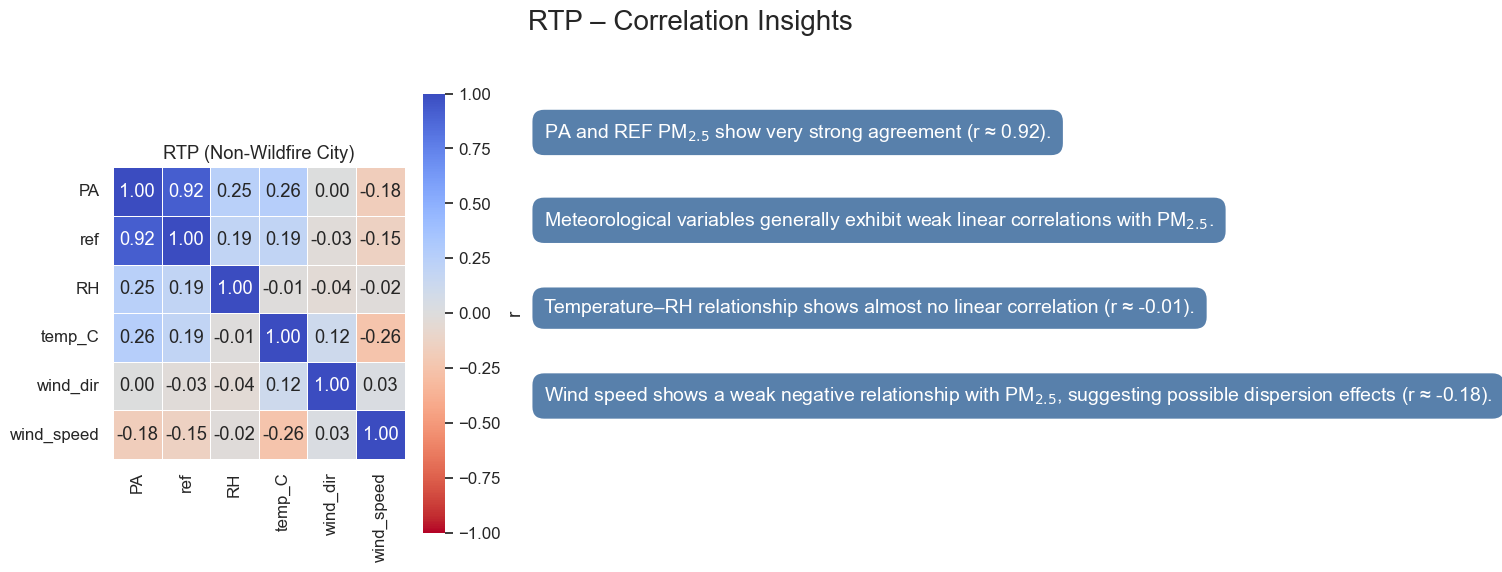

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="white", font_scale=1.1)

# -----------------------------
# Define city groups
# -----------------------------
wildfire_cities = ["Bend", "Oakridge"]
non_wildfire_cities = ["Wilmington", "RTP"]

# -----------------------------
# Helper function for wording
# -----------------------------
def describe_corr(val):
    if abs(val) < 0.05:
        return f"shows almost no linear correlation (r ≈ {val:.2f})."
    elif abs(val) < 0.20:
        return f"is weakly {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."
    elif abs(val) < 0.40:
        return f"is moderately {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."
    else:
        return f"is strongly {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."

# -----------------------------
# Function to generate insights
# -----------------------------
def generate_insights(corr):
    pa_ref = corr.loc['PA', 'ref']
    temp_rh = corr.loc['temp_C', 'RH']
    wind_pa = corr.loc['wind_speed', 'PA']

    # PA vs REF sentence
    if abs(pa_ref) > 0.9:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show very strong agreement (r ≈ {pa_ref:.2f})."
    elif abs(pa_ref) > 0.7:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show strong agreement (r ≈ {pa_ref:.2f})."
    else:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show moderate agreement (r ≈ {pa_ref:.2f})."

    # General meteorology sentence
    met_sentence = "Meteorological variables generally exhibit weak linear correlations with PM$_{2.5}$."

    # Temperature-RH sentence
    temp_rh_sentence = "Temperature–RH relationship " + describe_corr(temp_rh)

    # Wind speed vs PA sentence
    if abs(wind_pa) < 0.05:
        wind_sentence = f"Wind speed shows almost no linear relationship with PM$_{{2.5}}$ (r ≈ {wind_pa:.2f})."
    elif wind_pa < 0:
        wind_sentence = f"Wind speed shows a weak negative relationship with PM$_{{2.5}}$, suggesting possible dispersion effects (r ≈ {wind_pa:.2f})."
    else:
        wind_sentence = f"Wind speed shows a weak positive relationship with PM$_{{2.5}}$ (r ≈ {wind_pa:.2f})."

    return [pa_sentence, met_sentence, temp_rh_sentence, wind_sentence]

# -----------------------------
# Plot function
# -----------------------------
def plot_city_correlation(df, city_name):
    variables = ['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']
    corr = df[variables].corr()

    insights = generate_insights(corr)

    fig = plt.figure(figsize=(14, 6))

    # Heatmap axis
    ax1 = plt.subplot2grid((1, 2), (0, 0))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm_r",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={'label': 'r'},
        ax=ax1
    )

    if city_name in wildfire_cities:
        group = "Wildfire City"
    else:
        group = "Non-Wildfire City"

    ax1.set_title(f"{city_name} ({group})")

    # Insight panel
    ax2 = plt.subplot2grid((1, 2), (0, 1))
    ax2.axis('off')

    y = 0.9
    for text in insights:
        ax2.text(
            0.05,
            y,
            text,
            fontsize=14,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="#4f79a7",
                edgecolor="none",
                alpha=0.95
            ),
            color="white"
        )
        y -= 0.2

    plt.suptitle(f"{city_name} – Correlation Insights", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Load your datasets
# -----------------------------
bend = pd.read_csv("merged_results/Bend_PM_weather_hourly_EDA_ready.csv")
oakridge = pd.read_csv("merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv")
wilmington = pd.read_csv("merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv")
rtp = pd.read_csv("merged_results/RTP_PM_weather_hourly_EDA_ready.csv")

# -----------------------------
# Standardize column names
# -----------------------------
def prepare_df(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    # raw PA only
    if 'pa' in df.columns and 'PA' not in df.columns:
        df['PA'] = pd.to_numeric(df['pa'], errors='coerce')
    else:
        df['PA'] = pd.to_numeric(df['PA'], errors='coerce')

    if 'rh' in df.columns and 'RH' not in df.columns:
        df['RH'] = pd.to_numeric(df['rh'], errors='coerce')
    else:
        df['RH'] = pd.to_numeric(df['RH'], errors='coerce')

    df['ref'] = pd.to_numeric(df['ref'], errors='coerce')
    df['temp_C'] = pd.to_numeric(df['temp_C'], errors='coerce')
    df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
    df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

    return df[['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']].dropna()

bend = prepare_df(bend)
oakridge = prepare_df(oakridge)
wilmington = prepare_df(wilmington)
rtp = prepare_df(rtp)

# -----------------------------
# Generate plots
# -----------------------------
plot_city_correlation(bend, "Bend")
plot_city_correlation(oakridge, "Oakridge")
plot_city_correlation(wilmington, "Wilmington")
plot_city_correlation(rtp, "RTP")

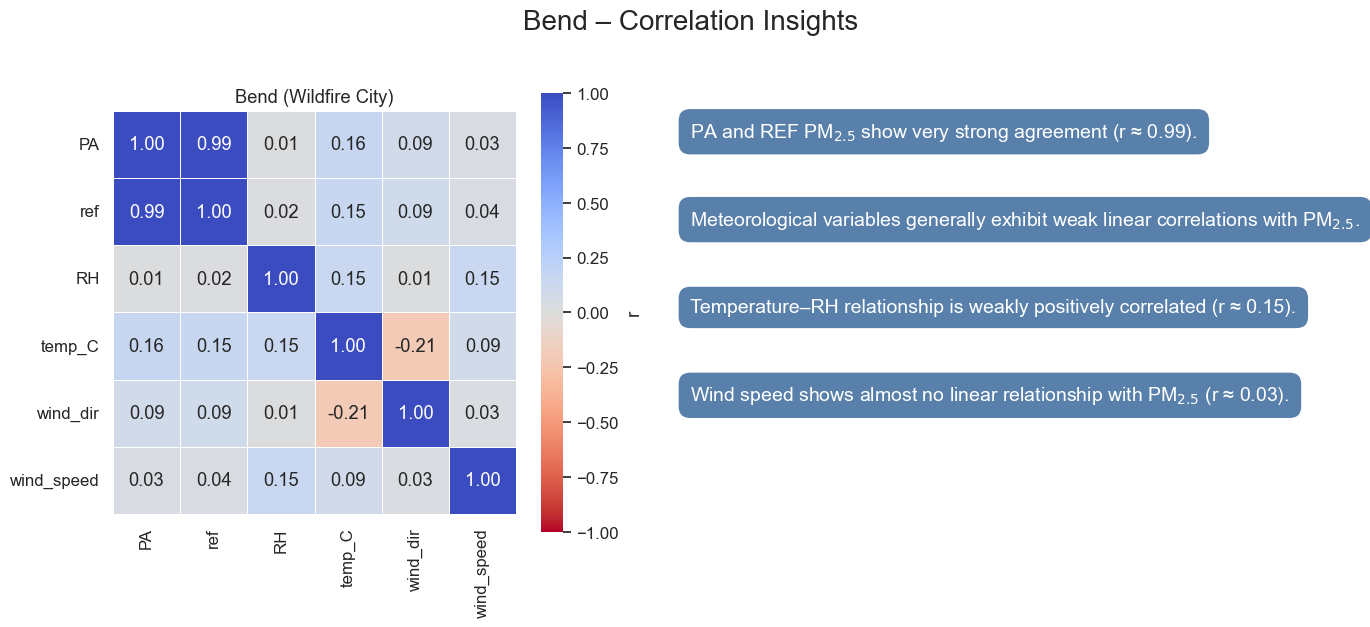

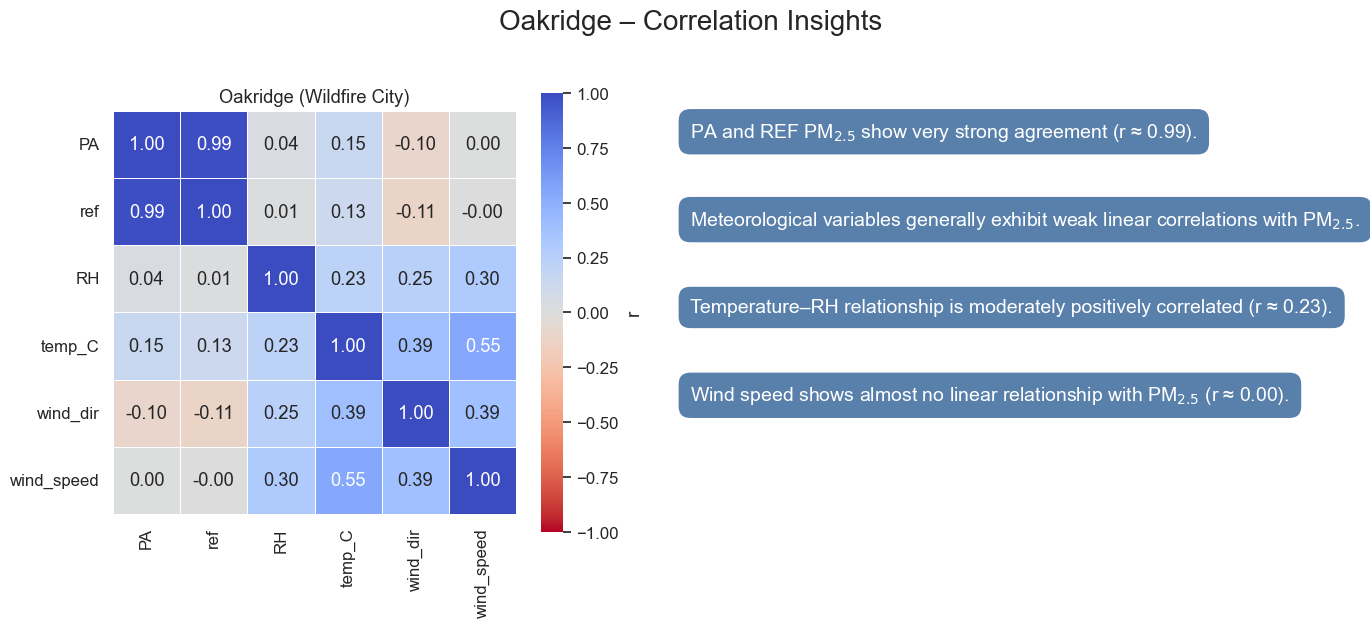

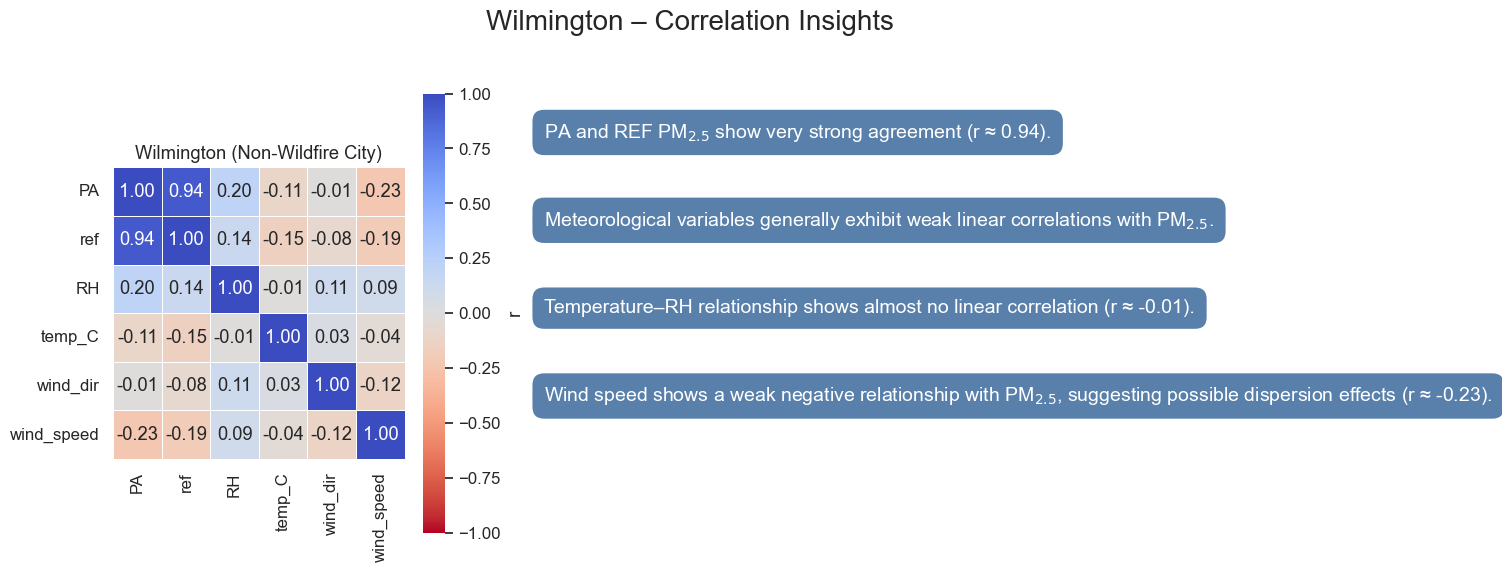

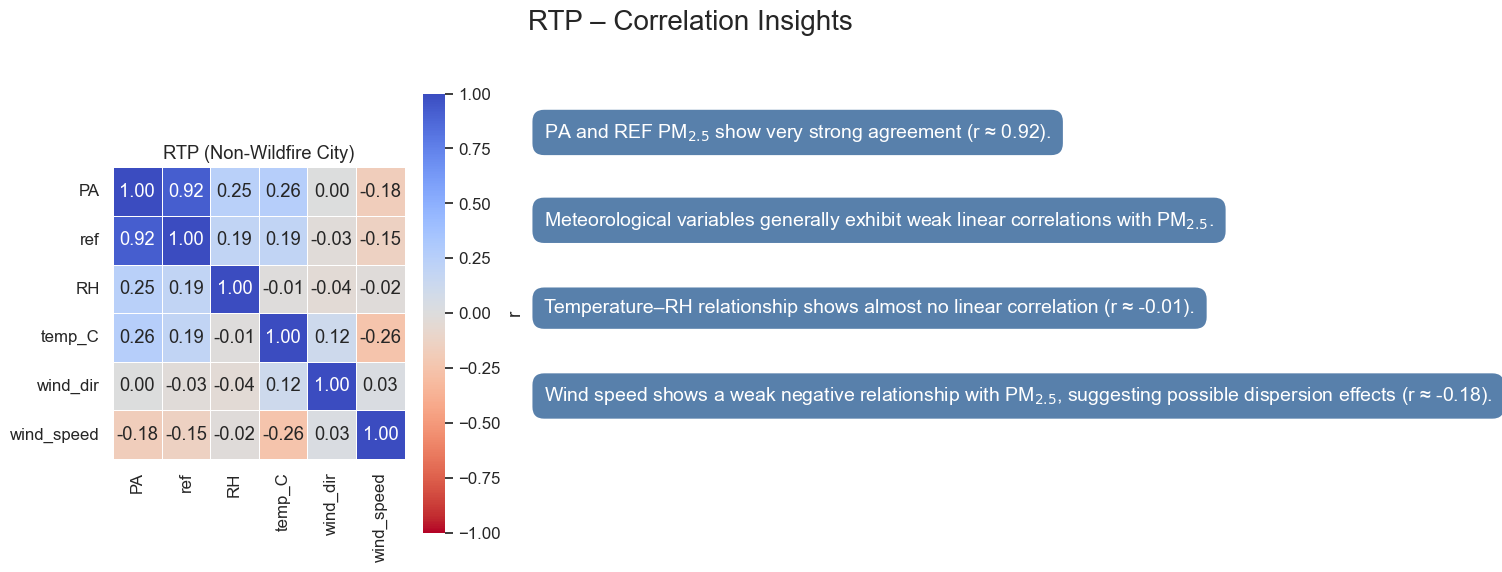

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="white", font_scale=1.1)

# -----------------------------
# Define city groups
# -----------------------------
wildfire_cities = ["Bend", "Oakridge"]
non_wildfire_cities = ["Wilmington", "RTP"]

# -----------------------------
# Helper function for wording
# -----------------------------
def describe_corr(val):
    if abs(val) < 0.05:
        return f"shows almost no linear correlation (r ≈ {val:.2f})."
    elif abs(val) < 0.20:
        return f"is weakly {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."
    elif abs(val) < 0.40:
        return f"is moderately {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."
    else:
        return f"is strongly {'positively' if val > 0 else 'negatively'} correlated (r ≈ {val:.2f})."

# -----------------------------
# Function to generate insights
# -----------------------------
def generate_insights(corr):
    pa_ref = corr.loc['PA', 'ref']
    temp_rh = corr.loc['temp_C', 'RH']
    wind_pa = corr.loc['wind_speed', 'PA']

    # PA vs REF sentence
    if abs(pa_ref) > 0.9:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show very strong agreement (r ≈ {pa_ref:.2f})."
    elif abs(pa_ref) > 0.7:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show strong agreement (r ≈ {pa_ref:.2f})."
    else:
        pa_sentence = f"PA and REF PM$_{{2.5}}$ show moderate agreement (r ≈ {pa_ref:.2f})."

    # General meteorology sentence
    met_sentence = "Meteorological variables generally exhibit weak linear correlations with PM$_{2.5}$."

    # Temperature-RH sentence
    temp_rh_sentence = "Temperature–RH relationship " + describe_corr(temp_rh)

    # Wind speed vs PA sentence
    if abs(wind_pa) < 0.05:
        wind_sentence = f"Wind speed shows almost no linear relationship with PM$_{{2.5}}$ (r ≈ {wind_pa:.2f})."
    elif wind_pa < 0:
        wind_sentence = f"Wind speed shows a weak negative relationship with PM$_{{2.5}}$, suggesting possible dispersion effects (r ≈ {wind_pa:.2f})."
    else:
        wind_sentence = f"Wind speed shows a weak positive relationship with PM$_{{2.5}}$ (r ≈ {wind_pa:.2f})."

    return [pa_sentence, met_sentence, temp_rh_sentence, wind_sentence]

# -----------------------------
# Plot function
# -----------------------------
def plot_city_correlation(df, city_name):
    variables = ['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']
    corr = df[variables].corr()

    insights = generate_insights(corr)

    fig = plt.figure(figsize=(14, 6))

    # Heatmap axis
    ax1 = plt.subplot2grid((1, 2), (0, 0))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm_r",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={'label': 'r'},
        ax=ax1
    )

    if city_name in wildfire_cities:
        group = "Wildfire City"
    else:
        group = "Non-Wildfire City"

    ax1.set_title(f"{city_name} ({group})")

    # Insight panel
    ax2 = plt.subplot2grid((1, 2), (0, 1))
    ax2.axis('off')

    y = 0.9
    for text in insights:
        ax2.text(
            0.05,
            y,
            text,
            fontsize=14,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="#4f79a7",
                edgecolor="none",
                alpha=0.95
            ),
            color="white"
        )
        y -= 0.2

    plt.suptitle(f"{city_name} – Correlation Insights", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Load your datasets
# -----------------------------
bend = pd.read_csv("merged_results/Bend_PM_weather_hourly_EDA_ready.csv")
oakridge = pd.read_csv("merged_results/Oakridge_PM_weather_hourly_EDA_ready.csv")
wilmington = pd.read_csv("merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv")
rtp = pd.read_csv("merged_results/RTP_PM_weather_hourly_EDA_ready.csv")

# -----------------------------
# Standardize column names
# -----------------------------
def prepare_df(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    # raw PA only
    if 'pa' in df.columns and 'PA' not in df.columns:
        df['PA'] = pd.to_numeric(df['pa'], errors='coerce')
    else:
        df['PA'] = pd.to_numeric(df['PA'], errors='coerce')

    if 'rh' in df.columns and 'RH' not in df.columns:
        df['RH'] = pd.to_numeric(df['rh'], errors='coerce')
    else:
        df['RH'] = pd.to_numeric(df['RH'], errors='coerce')

    df['ref'] = pd.to_numeric(df['ref'], errors='coerce')
    df['temp_C'] = pd.to_numeric(df['temp_C'], errors='coerce')
    df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
    df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

    return df[['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']].dropna()

bend = prepare_df(bend)
oakridge = prepare_df(oakridge)
wilmington = prepare_df(wilmington)
rtp = prepare_df(rtp)

# -----------------------------
# Generate plots
# -----------------------------
plot_city_correlation(bend, "Bend")
plot_city_correlation(oakridge, "Oakridge")
plot_city_correlation(wilmington, "Wilmington")
plot_city_correlation(rtp, "RTP")

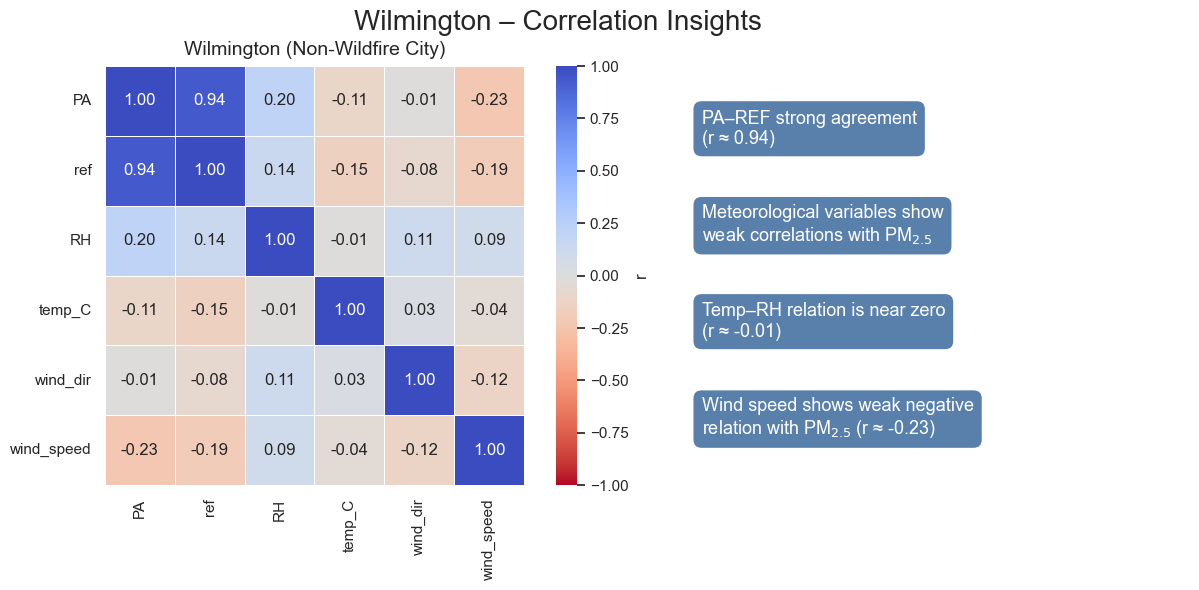

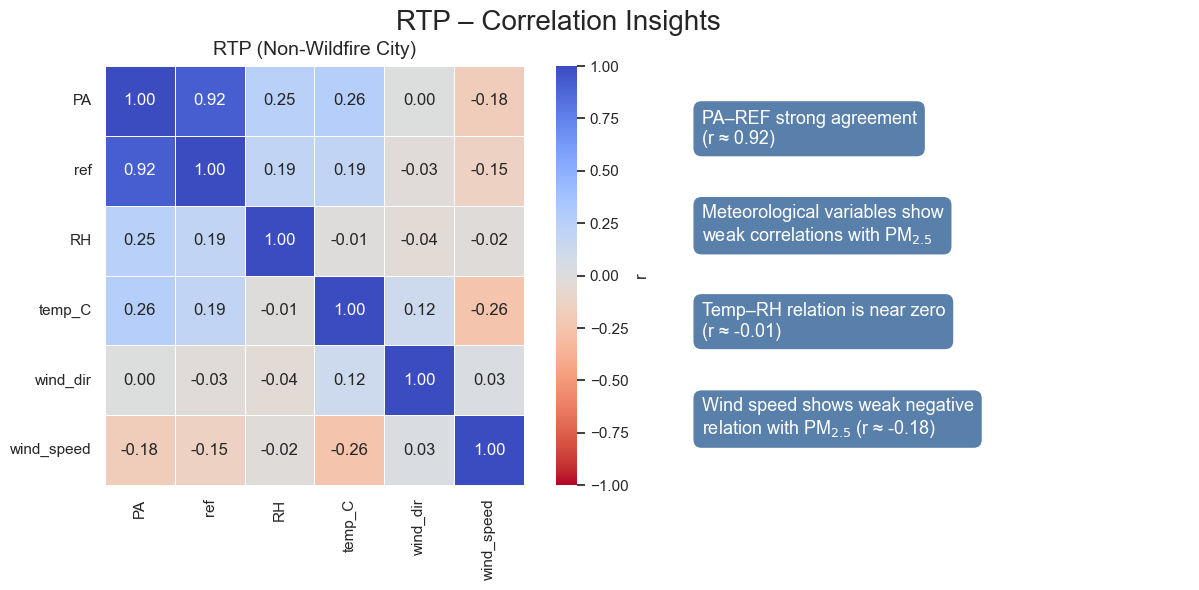

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white", font_scale=1.0)

# -----------------------------
# Short insight generator
# -----------------------------
def short_insights(corr):
    pa_ref = corr.loc['PA', 'ref']
    temp_rh = corr.loc['temp_C', 'RH']
    wind_pa = corr.loc['wind_speed', 'PA']

    insights = [
        f"PA–REF strong agreement\n(r ≈ {pa_ref:.2f})",
        "Meteorological variables show\nweak correlations with PM$_{2.5}$",
        f"Temp–RH relation is near zero\n(r ≈ {temp_rh:.2f})",
        f"Wind speed shows weak negative\nrelation with PM$_{{2.5}}$ (r ≈ {wind_pa:.2f})"
    ]
    return insights

# -----------------------------
# Plot function
# -----------------------------
def plot_city_correlation_clean(df, city_name):
    variables = ['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']
    corr = df[variables].corr()
    insights = short_insights(corr)

    fig = plt.figure(figsize=(13, 5.8))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1.0])

    # Heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm_r",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'r'},
        ax=ax1
    )
    ax1.set_title(f"{city_name} (Non-Wildfire City)", fontsize=14, pad=8)

    # Insights
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.axis("off")

    y_positions = [0.85, 0.62, 0.39, 0.16]
    for y, text in zip(y_positions, insights):
        ax2.text(
            0.03, y, text,
            fontsize=13,
            va="center",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor="#4f79a7",
                edgecolor="none",
                alpha=0.95
            ),
            color="white"
        )

    plt.suptitle(f"{city_name} – Correlation Insights", fontsize=20, y=0.98)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Load your files
# -----------------------------
wilmington = pd.read_csv("merged_results/Wilmington_PM_weather_hourly_EDA_ready.csv")
rtp = pd.read_csv("merged_results/RTP_PM_weather_hourly_EDA_ready.csv")

# -----------------------------
# Prepare dataframe
# -----------------------------
def prepare_df(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    df['PA'] = pd.to_numeric(df['pa'] if 'pa' in df.columns else df['PA'], errors='coerce')
    df['RH'] = pd.to_numeric(df['rh'] if 'rh' in df.columns else df['RH'], errors='coerce')
    df['ref'] = pd.to_numeric(df['ref'], errors='coerce')
    df['temp_C'] = pd.to_numeric(df['temp_C'], errors='coerce')
    df['wind_dir'] = pd.to_numeric(df['wind_dir'], errors='coerce')
    df['wind_speed'] = pd.to_numeric(df['wind_speed'], errors='coerce')

    return df[['PA', 'ref', 'RH', 'temp_C', 'wind_dir', 'wind_speed']].dropna()

wilmington = prepare_df(wilmington)
rtp = prepare_df(rtp)

# -----------------------------
# Generate plots
# -----------------------------
plot_city_correlation_clean(wilmington, "Wilmington")
plot_city_correlation_clean(rtp, "RTP")

         City   PA n  PA Median  REF n  REF Median
0        Bend   1758       8.03   1758        7.00
1    Oakridge   1865       6.16   1865        5.90
2  Wilmington   5705       6.58   5705        7.20
3         RTP   2350       7.62   2350        7.89
4  ALL CITIES  11678       6.93  11678        7.10


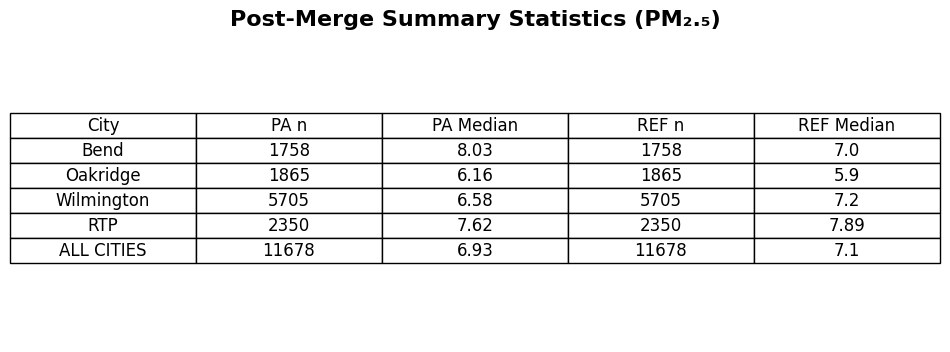

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the merged dataset you already created
# data_meteo should contain City, PA, ref

summary = []

cities = data_meteo["City"].unique()

for city in cities:
    
    df_city = data_meteo[data_meteo["City"] == city]

    pa_vals = df_city["PA"].dropna()
    ref_vals = df_city["ref"].dropna()

    summary.append([
        city,
        len(pa_vals),
        round(pa_vals.median(),2),
        len(ref_vals),
        round(ref_vals.median(),2)
    ])

summary_df = pd.DataFrame(summary, columns=[
    "City",
    "PA n",
    "PA Median",
    "REF n",
    "REF Median"
])

# Add overall row
summary_df.loc[len(summary_df)] = [
    "ALL CITIES",
    data_meteo["PA"].count(),
    round(data_meteo["PA"].median(),2),
    data_meteo["ref"].count(),
    round(data_meteo["ref"].median(),2)
]

print(summary_df)

# -----------------------------
# Plot table figure
# -----------------------------
fig, ax = plt.subplots(figsize=(10,4))
ax.axis('off')

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

plt.title("Post-Merge Summary Statistics (PM₂.₅)", fontsize=16, weight='bold')
plt.show()

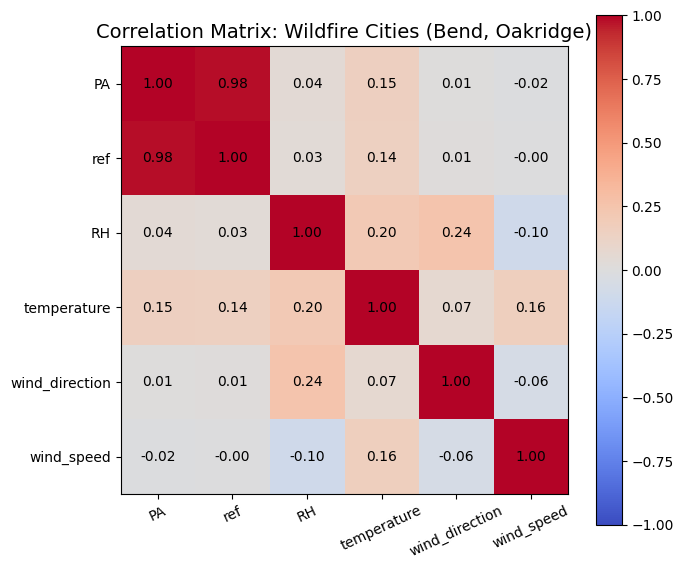

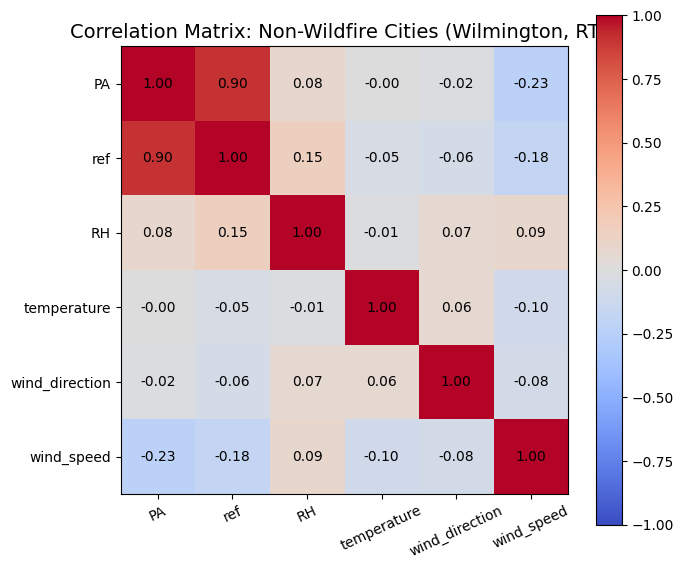

In [62]:
import matplotlib.pyplot as plt

# Define city groups
wildfire_cities = ["Bend", "Oakridge"]
non_wildfire_cities = ["Wilmington", "RTP"]

cols = ["PA", "ref", "RH", "temperature", "wind_direction", "wind_speed"]

# -------------------------
# Wildfire cities
# -------------------------
df_wildfire = data_meteo[data_meteo["City"].isin(wildfire_cities)][cols].dropna()

corr_wildfire = df_wildfire.corr()

plt.figure(figsize=(7,6))
im = plt.imshow(corr_wildfire, vmin=-1, vmax=1, cmap="coolwarm")

plt.xticks(range(len(cols)), cols, rotation=25)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Matrix: Wildfire Cities (Bend, Oakridge)", fontsize=14)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr_wildfire.iloc[i,j]:.2f}",
                 ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()


# -------------------------
# Non-Wildfire cities
# -------------------------
df_non_wildfire = data_meteo[data_meteo["City"].isin(non_wildfire_cities)][cols].dropna()

corr_non_wildfire = df_non_wildfire.corr()

plt.figure(figsize=(7,6))
im = plt.imshow(corr_non_wildfire, vmin=-1, vmax=1, cmap="coolwarm")

plt.xticks(range(len(cols)), cols, rotation=25)
plt.yticks(range(len(cols)), cols)

plt.title("Correlation Matrix: Non-Wildfire Cities (Wilmington, RTP)", fontsize=14)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr_non_wildfire.iloc[i,j]:.2f}",
                 ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()